In [11]:
# Uncomment to install the required packages
!pip install -U git+https://github.com/fagonzalezo/kdm.git@generative

  Cloning https://github.com/fagonzalezo/kdm.git (to revision generative) to /tmp/pip-req-build-c4ajixfn
  Running command git clone --filter=blob:none --quiet https://github.com/fagonzalezo/kdm.git /tmp/pip-req-build-c4ajixfn
  Running command git checkout -b generative --track origin/generative
  Switched to a new branch 'generative'
  Branch 'generative' set up to track remote branch 'generative' from 'origin'.
  Resolved https://github.com/fagonzalezo/kdm.git to commit a2290c4cfe5c8c67a556adfed62ac7edeff8f044
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for kdm: filename=kdm-1.0.0-py3-none-any.whl size=30885 sha256=374bce2cc328a6d996ea978d31f6bbeb4ab4c86c7c2a176ecbd9bda4b3c7ddb5
  Stored in directory: /tmp/pip-ephem-wheel-cache-setymz4t/wheels/04/16/53/e14d5346e39f04fd7f738b1af112407fb9e75401efce1e1d1e
Successfully built kdm


In [12]:
import numpy as np
from scipy.stats import norm
from scipy.stats import gaussian_kde

import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import optimizers
from keras import losses
from keras import metrics
from keras.callbacks import ModelCheckpoint


from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from kdm.models import KDMRegressModel
import kdm

from tqdm import tqdm

import matplotlib.pyplot as plt

In [13]:
import torch
import torchvision.transforms as T
dinov2_vits14 = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

dinov2_vits14.to(device)

transform_image = T.Compose([T.ToTensor(), T.Resize(244), T.CenterCrop(224), T.Normalize([0.5], [0.5])])

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth
100%|██████████| 84.2M/84.2M [00:00<00:00, 277MB/s]


# 3 Generative image regression from binary labels

We train a generative image classifier based on KDM. The dataset is a synthetic image classifier available at https://www.kaggle.com/datasets/gonzalorecioc/color-polygon-images. The images in the dataset correspond to polygons with different sizes, locations and colors. The dataset can be used for different classification and regression tasks. Here we will address a regression task, to estimate the radius of the enclosing circle of the polygon. However, we will address it as a classification task to see if the learned prototypes are able to capture the continuos nature of the underlining problem.

In [14]:
# Download dataset
# https://www.kaggle.com/datasets/gonzalorecioc/color-polygon-images
# You have to upload your Kaggle api key: https://www.kaggle.com/docs/api#authentication

def get_polygon_dataset():
    ! pip install -q kaggle
    from google.colab import files
    files.upload()
    !mkdir ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    import kagglehub

    # Download latest version
    path = kagglehub.dataset_download("gonzalorecioc/color-polygon-images")
    return path

path = get_polygon_dataset()

#path = "./"
print("Path to dataset files:", path)

Saving kaggle.json to kaggle (2).json
mkdir: cannot create directory ‘/root/.kaggle’: File exists
Path to dataset files: /root/.cache/kagglehub/datasets/gonzalorecioc/color-polygon-images/versions/1


In [15]:
# to run this example download the data from
# and set the paths accordingly
#path = "/Users/fgonza/Documents/research/code/data/color_poly_images/"
targets_path = path + "/targets.csv"
images_path = path + "/images/content/images/"

In [16]:
print(targets_path)
print(images_path)

/root/.cache/kagglehub/datasets/gonzalorecioc/color-polygon-images/versions/1/targets.csv
/root/.cache/kagglehub/datasets/gonzalorecioc/color-polygon-images/versions/1/images/content/images/


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the targets.csv file
targets_df = pd.read_csv(targets_path)

targets_df.head()

,Unnamed: 0,filename,sides,bg_color,fg_color,bound_circle_x,bound_circle_y,bound_circle_r,rotation
0,0,70aaa621-1345-4541-a954-ee9856daaf18.png,4,blue,pink,29,39,15,185
1,1,ea0d8d14-596a-4365-b007-6325fc96e0f4.png,3,black,yellow,66,66,21,215
2,2,48c1fc5a-8b6b-4555-bb6a-a7d42a5cedc2.png,4,yellow,red,59,103,20,59
3,3,ad721906-604c-4682-ae5d-15539ef1dbc7.png,3,green,pink,65,66,61,272
4,4,510dd5ea-fb92-432e-91cc-ed4654a03ebd.png,6,white,green,48,56,42,38


In [18]:
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image

class PolygonDataset(Dataset):
    def __init__(self, dataframe, images_dir, transform=None):
        self.dataframe = dataframe
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Read the image path from targets_df
        row = self.dataframe.iloc[idx]
        file_name = row['filename']
        img_path = os.path.join(self.images_dir, file_name)
        # Open and convert image to RGB
        image = Image.open(img_path).convert("RGB")
        # Apply the given transforms
        if self.transform:
            image = self.transform(image)
        # Use 'bound_circle_r' as the target label (adjust if needed)
        target = row['bound_circle_r']
        return image, target

# Create the dataset
polygon_dataset = PolygonDataset(targets_df, images_path, transform=transform_image)

# Create the DataLoader
polygon_dataloader = DataLoader(polygon_dataset, batch_size=32, shuffle=False)

# Calculate the embedding for each image in polygon_dataloader
embeddings = []
for images, _ in tqdm(polygon_dataloader):
    images = images.to(device)
    with torch.no_grad():
        outputs = dinov2_vits14(images)
        embeddings.append(outputs.cpu().numpy())


100%|██████████| 313/313 [01:11<00:00,  4.35it/s]


In [19]:
emb_array = np.concatenate(embeddings, axis=0)
# add the embedings to the targets_df
targets_df['embedding'] = list(emb_array)
targets_df.head()

,Unnamed: 0,filename,sides,bg_color,fg_color,bound_circle_x,bound_circle_y,bound_circle_r,rotation,embedding
0,0,70aaa621-1345-4541-a954-ee9856daaf18.png,4,blue,pink,29,39,15,185,"[-0.5633606, 2.3609521, -0.46001208, -2.741361..."
1,1,ea0d8d14-596a-4365-b007-6325fc96e0f4.png,3,black,yellow,66,66,21,215,"[-3.0232463, 1.4725623, -2.8498447, -2.7854695..."
2,2,48c1fc5a-8b6b-4555-bb6a-a7d42a5cedc2.png,4,yellow,red,59,103,20,59,"[-1.1544116, -0.10021329, -1.0100253, -3.82071..."
3,3,ad721906-604c-4682-ae5d-15539ef1dbc7.png,3,green,pink,65,66,61,272,"[-2.1182103, 0.6241626, -1.9022436, -1.1412241..."
4,4,510dd5ea-fb92-432e-91cc-ed4654a03ebd.png,6,white,green,48,56,42,38,"[-2.6369042, 0.38315153, -2.649141, -2.692696,..."


In [20]:

# split the data into train and test
train_df, test_df = train_test_split(targets_df, test_size=0.2, random_state=42)

# Print the maximum and minumum values of bound_circle_r column
print(f"Maximum bound_circle_r: {train_df['bound_circle_r'].max()}")
print(f"Minimum bound_circle_r: {train_df['bound_circle_r'].min()}")

Maximum bound_circle_r: 66
Minimum bound_circle_r: 10


In [22]:
import tensorflow as tf
import pandas as pd

def create_tf_dataset(dataframe, target_column='rotation',
                      batch_size=32, image_folder_path='',
                      shuffle=True, add_noise=False):
    """
    Converts a Pandas DataFrame into a TensorFlow dataset for image classification.

    Args:
        dataframe (pd.DataFrame): The input DataFrame containing image filenames and target labels.
        target_column (str, optional): The column name in the DataFrame representing the target labels.
                                       Defaults to 'rotation'.
        batch_size (int, optional): The batch size for the dataset. Defaults to 32.
        image_folder_path (str, optional): The path to the folder containing the images. Defaults to ''.
        shuffle (bool, optional): Whether to shuffle the dataset. Defaults to True.

    Returns:
        tf.data.Dataset: A TensorFlow dataset with preprocessed images and corresponding labels.
                           Images are loaded, resized, and normalized.
                           Target labels are scaled to a range between 0.1 and 0.9.
    """
    # Drop the 'Unnamed: 0' column if it exists
    if 'Unnamed: 0' in dataframe.columns:
        dataframe = dataframe.drop(columns=['Unnamed: 0'])

    embeddings = dataframe['embedding'].values
    embeddings = np.array([np.array(x) for x in embeddings])
    target = dataframe[target_column].values / 70.# Normalize the target values
    # add noise
    if add_noise:
        target = target + np.random.normal(0, 0.1, target.shape)
        target = np.clip(target, 0, 1)

    # make target binary label
    target = (target > 0.5).astype(float)
    target = target.reshape(-1, 1)
    target = tf.cast(target, tf.float32)
    # make target a ohe
    #target = keras.utils.to_categorical(target, num_classes=2)
    #target = target[:,1:]

    # Scale the target to [0.1, 0.9]
    #target = (target - np.min(target)) / (np.max(target) - np.min(target)) * 0.8 + 0.1

    # Create a TensorFlow dataset from image paths and targets
    dataset = tf.data.Dataset.from_tensor_slices((embeddings, target))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe))  # Shuffle if shuffle=True

    dataset = (dataset
                .batch(batch_size)
                .prefetch(buffer_size=tf.data.AUTOTUNE))

    return dataset

In [23]:
import tensorflow as tf

train_ds = create_tf_dataset(train_df, target_column='bound_circle_r',
                             batch_size=128, image_folder_path=images_path,
                             shuffle=True, add_noise=True)

test_ds = create_tf_dataset(test_df, target_column='bound_circle_r',
                            batch_size=32, image_folder_path=images_path,
                            shuffle=False, add_noise=False)


In [24]:
# prompt: For both train_ds and test_ds count the number of elements in each class

import numpy as np

# Assuming 'train_ds' and 'test_ds' are tf.data.Datasets
# Iterate through the datasets and count elements in each class
def count_class_elements(dataset):
    class_counts = {}
    for images, labels in dataset:
        for label in labels.numpy():
            class_idx = np.argmax(label) # Assuming one-hot encoding
            class_counts[class_idx] = class_counts.get(class_idx, 0) + 1
    return class_counts

train_class_counts = count_class_elements(train_ds)
test_class_counts = count_class_elements(test_ds)

print("Train Class Counts:", train_class_counts)
print("Test Class Counts:", test_class_counts)

Train Class Counts: {0: 8000}
Test Class Counts: {0: 2000}


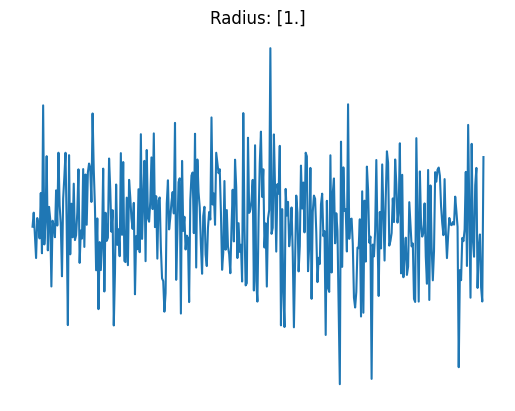

9.172867 -8.455525
(384,)


In [25]:
# read an image from the dataset and plot it
for image, label in train_ds.take(1):
    plt.plot(image[0].numpy())
    plt.title(f"Radius: {label[0].numpy()}")
    plt.axis('off')
    plt.show()
    print(np.max(image[0].numpy()), np.min(image[0].numpy()))
    print(image[0].shape)

In [26]:
def create_encoder(input_shape, layer_sizes):
    """
    Creates an encoder model.

    Args:
        input_shape (tuple): Shape of the encoder input.
        layer_sizes (list): List of integers specifying the hidden layer sizes.
            The last element is the encoded size.
            If empty, a simple Identity model is returned.
    Returns:
        keras.Model: The encoder model.
    """
    inputs = keras.Input(shape=input_shape)
    x = inputs
    if layer_sizes:
        for hidden_size in layer_sizes[:-1]:
            x = keras.layers.Dense(hidden_size, activation=keras.activations.gelu)(x)
        x = keras.layers.Dense(layer_sizes[-1])(x)
        #outputs = keras.layers.UnitNormalization(axis=-1)(x)
        outputs = x
        encoder = keras.Model(inputs, outputs, name="encoder")
    else:
        #encoder = keras.Sequential([keras.layers.UnitNormalization(axis=-1)])
        encoder = keras.Sequential([keras.layers.Identity()])
    return encoder


def train_disc_regress_model(input_shape,
                   layer_sizes=[],
                   wmp_epochs=0,
                   n_comp=64,
                   sigma_mult=1.0,
                   epochs=10,
                   batch_size=128,):

    if len(layer_sizes) == 0:
        encoded_size = input_shape[0]
    else:
        encoded_size = layer_sizes[-1]
    encoder = create_encoder(input_shape=input_shape, layer_sizes=layer_sizes)
    print(encoder.summary())
    if wmp_epochs > 0:
        # warm up the encoder with a small subset
        encoder_wmp = keras.Sequential([encoder,
                                        keras.layers.Dense(1, activation='sigmoid')])
        encoder_wmp.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                        loss=losses.binary_crossentropy,
                        metrics=[metrics.binary_accuracy])
        # train the encoder for 2 epoch
        subset_ds = train_ds
        encoder_wmp.fit(subset_ds, epochs=wmp_epochs, verbose=1)
    # Create a KDM classifier model
    kdm_disc = KDMRegressModel(encoded_size=encoded_size,
                                dim_y=1,
                                encoder=encoder,
                                n_comp=n_comp,
                            sigma_x=0.2,
                            sigma_y=0.3,
                            min_sigma_y=0.15,
                            generative=0.,
                            sigma_x_trainable=True)

    # initialize the prototypes using random sample from train_ds
    init_prot_x = []
    init_prot_y = []
    for image, label in train_ds.unbatch().take(n_comp):
        init_prot_x.append(image[None, ...])
        init_prot_y.append(label)
    init_prot_x = np.concatenate(init_prot_x, axis=0)
    print(init_prot_x.shape)
    init_prot_y = np.array(init_prot_y)
    kdm_disc.init_components(init_prot_x, init_prot_y,
                            init_sigma=True, sigma_mult=sigma_mult)
    print(f"Sigma: {kdm_disc.kdm.kernel.sigma.numpy()}")
    # Compile the model
    kdm_disc.compile(optimizer=optimizers.Adam(learning_rate=1e-4))

    # Callback to save the best model
    checkpoint = keras.callbacks.ModelCheckpoint('best_model.weights.h5',
                                                 save_best_only=True,
                                                 save_weights_only=True)

    # train the classifier
    #kdm_disc.predict(X_train[:10])
    history = kdm_disc.fit(train_ds,
                  epochs=epochs,
                  batch_size=batch_size,
                  callbacks=[checkpoint],
                  validation_data=test_ds,
                  verbose=1)

    kdm_disc.load_weights('best_model.weights.h5')

    # Evaluate the classifier
    score = kdm_disc.evaluate(test_ds, verbose=0)
    # calculate accuracy
    y_pred, y_var = kdm_disc.predict_reg(test_ds)
    y_pred_class = (y_pred > 0.5).astype(int).flatten()
    y_test_class =  test_ds.map(lambda x, y: y).unbatch()
    y_test_class = np.concatenate([y for _, y in test_ds.unbatch()], axis=0)
    y_test_class = (y_test_class > 0.5).astype(int)
    accuracy = np.mean(y_pred_class == y_test_class)
    print(f"Test Accuracy: {accuracy}")
    print('Test loss:', score)
    print(f'Sigma x: {kdm_disc.kernel.sigma.numpy()}')
    print(f'Sigma y: {kdm_disc.sigma_y.numpy()}')

    return kdm_disc, history


In [27]:
input_shape=(384,)
layer_sizes=[32]
num_components = 128
kdm_disc_1, history = train_disc_regress_model(input_shape=input_shape,
                                   layer_sizes=layer_sizes,
                                   n_comp=128,
                                   sigma_mult=1.0,
                                   wmp_epochs=2,
                                   epochs=2,
                                   batch_size=128)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │          12,320 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,320 (48.12 KB)

 Trainable params: 12,320 (48.12 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - binary_accuracy: 0.7357 - loss: 0.9891
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - binary_accuracy: 0.8897 - loss: 0.2810
(128, 384)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Sigma: 6.734855651855469
Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: -0.3014 - val_loss: -0.4699
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: -0.4012 - val_loss: -0.5301
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Test Accuracy: 0.961
Test loss: -0.5300948023796082
Sigma x: 6.725199222564697
Sigma y: 0.28730112314224243


In [28]:
def train_gen_regress_model(input_shape,
                   layer_sizes=[],
                   n_comp=64,
                   sigma_mult=0.2,
                   sigma_x_trainable=False,
                   epochs=20,
                   batch_size=128,
                   kdm_disc=None):
    if len(layer_sizes) == 0:
        encoded_size = input_shape[0]
    else:
        encoded_size = layer_sizes[-1]

    encoder = create_encoder(input_shape=input_shape, layer_sizes=layer_sizes)
    encoder.set_weights(kdm_disc.encoder.get_weights())

    # Create a KDM classifier model
    kdm_gen = KDMRegressModel(encoded_size=encoded_size,
                                dim_y=1,
                                encoder=encoder,
                                n_comp=n_comp,
                            sigma_x=kdm_disc.kernel.sigma.numpy() * sigma_mult,
                            sigma_y=0.3,
                            min_sigma_y=0.15,
                            generative=1.,
                            sigma_x_trainable=sigma_x_trainable)

    # initialize the prototypes using random sample from train_ds
    init_prot_x = []
    init_prot_y = []
    for image, label in train_ds.unbatch().take(n_comp):
        init_prot_x.append(image[None, ...])
        init_prot_y.append(label)
    init_prot_x = np.concatenate(init_prot_x, axis=0)
    print(init_prot_x.shape)
    init_prot_y = np.array(init_prot_y)
    kdm_gen.init_components(init_prot_x, init_prot_y,
                            init_sigma=False)
    print(f"Sigma: {kdm_gen.kdm.kernel.sigma.numpy()}")
    # Compile the model
    kdm_gen.compile(optimizer=optimizers.Adam(learning_rate=1e-3))

    # Callback to save the best model
    checkpoint = keras.callbacks.ModelCheckpoint('best_model_gen.weights.h5',
                                                 save_best_only=True,
                                                 save_weights_only=True)

    # train the classifier
    history = kdm_gen.fit(train_ds,
                  epochs=epochs,
                  batch_size=batch_size,
                  callbacks=[checkpoint],
                  validation_data=test_ds,
                  verbose=1)

    kdm_gen.load_weights('best_model_gen.weights.h5')

    y_pred, y_var = kdm_gen.predict_reg(test_ds)
    y_pred_class = (y_pred > 0.5).astype(int).flatten()
    y_test_class = np.concatenate([y for _, y in test_ds.unbatch()], axis=0)
    y_test_class = (y_test_class > 0.5).astype(int)
    accuracy = np.mean(y_pred_class == y_test_class)

    # Evaluate the classifier
    score = kdm_gen.evaluate(test_ds, verbose=0)
    print('Test loss:', score)
    print('Test accuracy:', accuracy)
    sigma_x, sigma_y = kdm_gen.get_sigmas()
    print(f'Sigma_x: {sigma_x}')
    print(f'Sigma_y: {sigma_y}')

    return kdm_gen, history


In [29]:
num_components = 128
kdm_gen_1, history = train_gen_regress_model(input_shape=input_shape,
                                   layer_sizes=layer_sizes,
                                      sigma_mult=0.7,
                                      n_comp=num_components,
                                      epochs=20,
                                      batch_size=128,
                                      kdm_disc=kdm_disc_1)

(128, 384)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Sigma: 4.707639694213867
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 135.1953 - val_loss: 134.8729
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 134.8451 - val_loss: 134.4302
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 134.4338 - val_loss: 134.2881
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 134.3763 - val_loss: 134.2308
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 134.2953 - val_loss: 134.1724
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 134.2433 - val_loss: 134.1234
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 134.2022 - val_loss: 134.0782
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 134.1731 - val_loss: 134.0351
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 134.1128 - val_loss: 133.9931
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 134.0750 - val_loss: 133.9624
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━

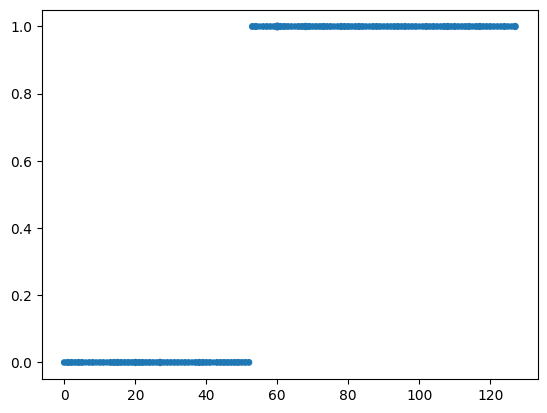

In [30]:
# plot y prototypes
xs = kdm_gen_1.kdm.c_x.numpy()
ys = kdm_gen_1.kdm.c_y.numpy()
weights = np.abs(kdm_gen_1.kdm.c_w.numpy())
weights /= np.sum(weights)


sorted_ys = ys.flatten()
idx = np.argsort(sorted_ys)


sorted_xs = xs[idx]
sorted_ys = sorted_ys[idx]
sorted_weights = weights[idx]


# create prototypes_df using sorted xs, ys and weights
prototypes_df = pd.DataFrame({'x': sorted_xs.tolist(),  'y':sorted_ys, 'w': sorted_weights})

plt.scatter(np.arange(len(prototypes_df['y'])),
            prototypes_df['y'], s=prototypes_df['w']*2000)

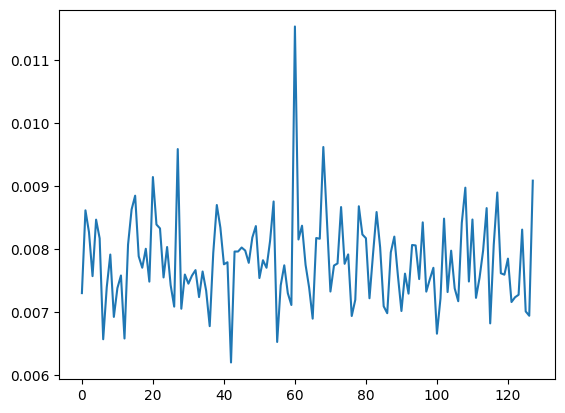

In [31]:
plt.plot(sorted_weights)

In [32]:
from kdm.utils import pure2dm
from kdm.utils import dm_rbf_expectation

def adjust_gen_model(input_shape,
                    layer_sizes=[],
                    kdm_gen=None):
    encoded_size = kdm_gen.encoded_size
    n_comp = kdm_gen.n_comp
    encoder = create_encoder(input_shape=input_shape,
                                   layer_sizes=layer_sizes)
    encoder.set_weights(kdm_gen.encoder.get_weights())
    sigma_x, sigma_y = kdm_gen.get_sigmas()

    # Create a KDM classifier model
    kdm_gen_adj = KDMRegressModel(encoded_size=encoded_size,
                                dim_y=1,
                                encoder=encoder,
                                n_comp=n_comp,
                            sigma_x=sigma_x,
                            sigma_y=sigma_y,
                            min_sigma_y=sigma_y,
                            generative=1.,
                            sigma_x_trainable=False,
                            x_train=False,
                            y_train=False,
                            w_train=True)

    kdm_gen_adj.compile(optimizer=optimizers.Adam(learning_rate=5e-3))
    kdm_gen_adj.kdm.c_y.assign(kdm_gen.kdm.c_y)
    kdm_gen_adj.kdm.c_w.assign(kdm_gen.kdm.c_w)
    kdm_gen_adj.kdm.c_x.assign(kdm_gen.kdm.c_x)

    x_prot = kdm_gen.kdm.c_x
    rho_x = pure2dm(x_prot)
    rho_y = kdm_gen.kdm(rho_x)
    y_prot_pred = keras.ops.convert_to_numpy(dm_rbf_expectation(rho_y))
    kdm_gen_adj.kdm.c_y.assign(y_prot_pred)

    # Callback to save the best model
    checkpoint = keras.callbacks.ModelCheckpoint('best_model_gen_adj.weights.h5',
                                                 save_best_only=True,
                                                 save_weights_only=True)

    # train the classifier
    history=[]
    '''
    history = kdm_gen_adj.fit(train_ds,
                  epochs=epochs,
                  batch_size=batch_size,
                  callbacks=[checkpoint],
                  validation_data=test_ds,
                  verbose=1)
    kdm_gen_adj.load_weights('best_model_gen_adj.weights.h5')
    '''

    y_pred, y_var = kdm_gen_adj.predict_reg(test_ds)
    y_pred_class = (y_pred > 0.5).astype(int).flatten()
    y_test_class = np.concatenate([y for _, y in test_ds.unbatch()], axis=0)
    y_test_class = (y_test_class > 0.5).astype(int)
    accuracy = np.mean(y_pred_class == y_test_class)
    print(f"Accuracy: {accuracy}")

    # Evaluate the classifier
    score = kdm_gen_adj.evaluate(test_ds, verbose=0)
    print('Test loss:', score)
    print('Test accuracy:', accuracy)
    print(f'Sigma x: {kdm_gen.kernel.sigma.numpy()}')
    print(f'Sigma y: {kdm_gen.sigma_y.numpy()}')

    return kdm_gen_adj, history


In [33]:
kdm_gen_adj, history = adjust_gen_model(input_shape=input_shape,
                                layer_sizes=layer_sizes,
                                kdm_gen=kdm_gen_1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy: 0.943
Test loss: 134.19219970703125
Test accuracy: 0.943
Sigma x: 4.707639694213867
Sigma y: 0.15000000596046448


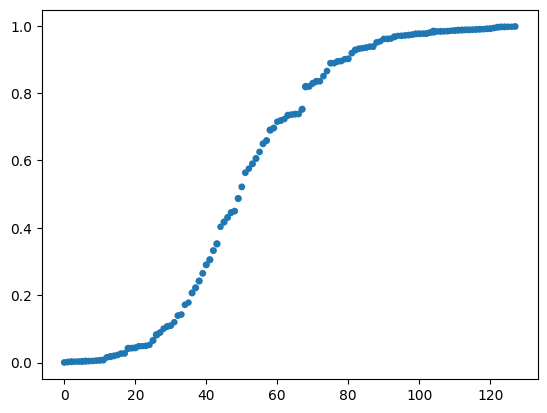

In [34]:
# plot y prototypes
xs = kdm_gen_adj.kdm.c_x.numpy()
ys = kdm_gen_adj.kdm.c_y.numpy()
weights = np.abs(kdm_gen_adj.kdm.c_w.numpy())
weights /= np.sum(weights)


sorted_ys = ys.flatten()
idx = np.argsort(sorted_ys)


sorted_xs = xs[idx]
sorted_ys = sorted_ys[idx]
sorted_weights = weights[idx]

plt.scatter(np.arange(len(sorted_xs)),
            sorted_ys, s=weights*2000)

# create prototypes_df
prototypes_df = pd.DataFrame({'x': xs.tolist(),  'y':ys.flatten(), 'w': weights})


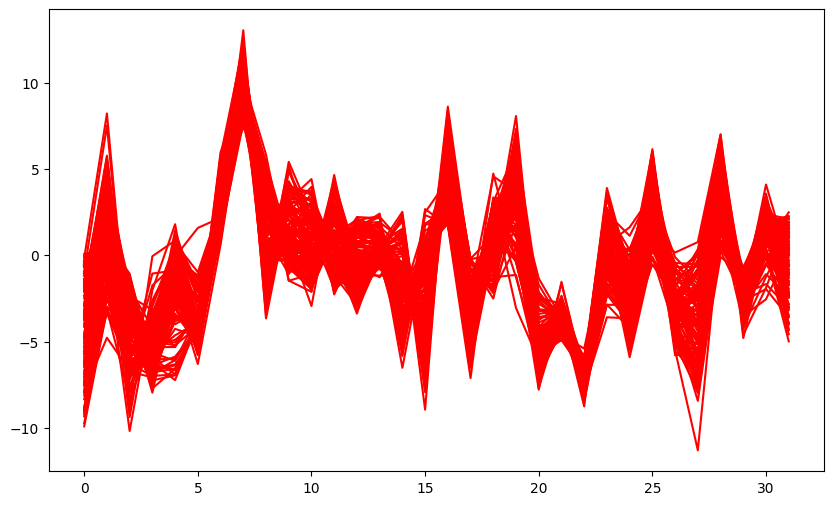

In [35]:
import matplotlib.pyplot as plt

# Assuming prototypes_df and train_df_encoded are defined as in your code

plt.figure(figsize=(10, 6))  # Adjust figure size as needed

for index, row in prototypes_df.iterrows():
    prototype_encoding = row['x']


    # Plot the prototype's encoding vector
    plt.plot(np.arange(len(prototype_encoding)), prototype_encoding, color='red', label='Prototype Encoding')
plt.show()

In [36]:
encoded_size = 384
encoder_1 = create_encoder(input_shape=input_shape, layer_sizes=layer_sizes)
encoder_1.set_weights(kdm_disc_1.encoder.get_weights())

train_ds_noshuf = create_tf_dataset(train_df, target_column='bound_circle_r',
                             batch_size=128, image_folder_path=images_path,
                                    shuffle=False)



In [37]:
# prompt: Encode the images in train_ds_noshuf.
# Create a copy of train_df and add the encoding vector as a new column.

# Encode the images in train_ds_noshuf
encoded_images = encoder_1.predict(train_ds_noshuf)

# Create a copy of train_df
train_df_encoded = train_df.copy()

#reset indices
train_df_encoded.reset_index(drop=True, inplace=True)

# Add the encoding vector as a new column
train_df_encoded['encoding'] = encoded_images.tolist()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [38]:
# prompt: Use sklearn to find the k-nearest neighbors of each prototype in prototypes_df. in encoded images.
# Store the indices of the nn as a list in a column of a  prototypes_df.

from sklearn.neighbors import NearestNeighbors

# Assuming 'prototypes_df' and 'encoded_images' are defined as in your provided code

# Create a NearestNeighbors model with k=5 (you can adjust k as needed)
knn_model = NearestNeighbors(n_neighbors=20)

# Fit the model on the encoded images
knn_model.fit(encoded_images)

# Find the k-nearest neighbors for each prototype in prototypes_df
prototype_encodings = np.array([x for x in prototypes_df['x'].values])
distances, indices = knn_model.kneighbors(prototype_encodings)

# Store the indices of the nearest neighbors as a list in a new column 'nn_indices'
prototypes_df['nn_indices'] = indices.tolist()

In [39]:
# prompt: For each prototype, calculate the average and std deviation of the bound_circle_r attribute of the nearest neighbors

# Assuming prototypes_df and train_df_encoded are defined as in your code

# Calculate average and std deviation of 'bound_circle_r' for nearest neighbors
prototypes_df['nn_bound_circle_r_avg'] = 0.0
prototypes_df['nn_bound_circle_r_std'] = 0.0

for index, row in prototypes_df.iterrows():
    nn_indices = row['nn_indices']
    nn_bound_circle_r = train_df_encoded.iloc[nn_indices]['bound_circle_r'].values
    prototypes_df.at[index, 'nn_bound_circle_r_avg'] = np.mean(nn_bound_circle_r)
    prototypes_df.at[index, 'nn_bound_circle_r_std'] = np.std(nn_bound_circle_r)

print(prototypes_df[['nn_bound_circle_r_avg', 'nn_bound_circle_r_std']])

     nn_bound_circle_r_avg  nn_bound_circle_r_std
0                    30.15               2.535251
1                    16.90               3.477068
2                    20.35               2.850877
3                    20.15               2.669738
4                    53.40               4.397727
..                     ...                    ...
123                  17.40               3.583295
124                  49.00               3.464102
125                  37.40               3.215587
126                  51.00               4.785394
127                  47.45               3.734635

[128 rows x 2 columns]


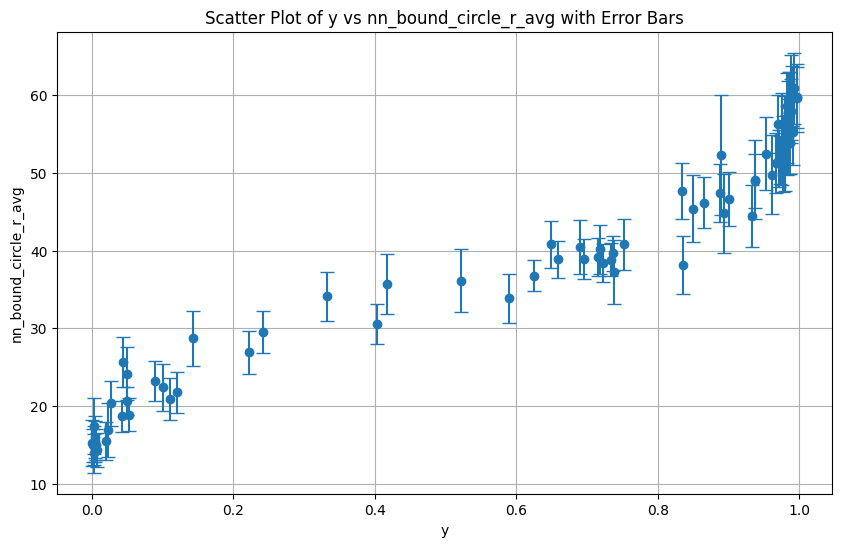

In [40]:
# prompt: Make a scatter plot of the y column vs nn_bound_circle_r_avg column using nn_bound_circle_r_std as error bars

# Calculate the 50th percentile of the 'w' column
percentile = prototypes_df['w'].quantile(0.4)

# Create a copy of prototypes_df with prototypes above the 50th percentile
prototypes_df_top = prototypes_df[prototypes_df['w'] >= percentile].copy()


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.errorbar(prototypes_df_top['y'], prototypes_df_top['nn_bound_circle_r_avg'],
             yerr=prototypes_df_top['nn_bound_circle_r_std'], fmt='o', capsize=5)
plt.xlabel('y')
plt.ylabel('nn_bound_circle_r_avg')
plt.title('Scatter Plot of y vs nn_bound_circle_r_avg with Error Bars')
plt.grid(True)
plt.show()

Prototype 53:
- Weight: 0.008170105516910553
- y value: 0.004425335209816694
- nn_bound_circle_r_avg: 15.45
- nn_bound_circle_r_std: 2.6358110706194404


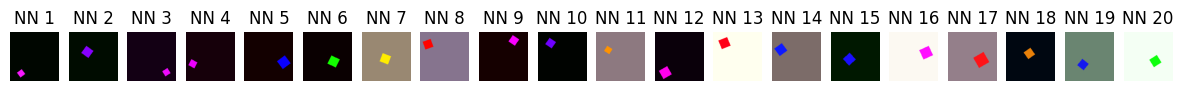

In [41]:
# prompt: for a particular prototype given by prot_idx (prototype index):
# - print its weight and y value
# - show the nn images using the image path in train_df_encoded

import matplotlib.pyplot as plt

# Assuming prototypes_df and train_df_encoded are defined as in your code

prot_idx = 53  # Replace with the desired prototype index

# Print the weight and y value for the specified prototype
print(f"Prototype {prot_idx}:")
print(f"- Weight: {prototypes_df['w'][prot_idx]}")
print(f"- y value: {prototypes_df['y'][prot_idx]}")
print(f"- nn_bound_circle_r_avg: {prototypes_df['nn_bound_circle_r_avg'][prot_idx]}")
print(f"- nn_bound_circle_r_std: {prototypes_df['nn_bound_circle_r_std'][prot_idx]}")

# Show the NN images
nn_indices = prototypes_df['nn_indices'][prot_idx]

plt.figure(figsize=(15, 5))  # Adjust figure size as needed

for i, img_idx in enumerate(nn_indices):
  img_path = images_path + "/" + train_df_encoded['filename'][img_idx]
  img = plt.imread(img_path)
  plt.subplot(1, len(nn_indices), i + 1)
  plt.imshow(img)
  plt.title(f"NN {i+1}")
  plt.axis('off')
plt.show()

Prototype 1:
- Weight: 0.00778075959533453
- y value: 0.022707035765051842
- nn_bound_circle_r_avg: 16.9
- nn_bound_circle_r_std: 3.477067730142742


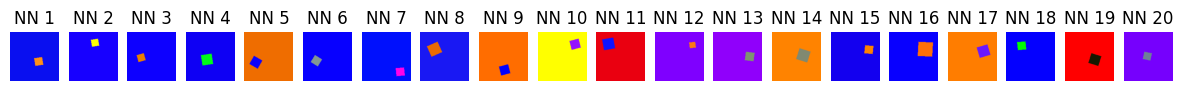

Prototype 10:
- Weight: 0.007885239087045193
- y value: 0.006707465276122093
- nn_bound_circle_r_avg: 14.35
- nn_bound_circle_r_std: 2.1277922830953213


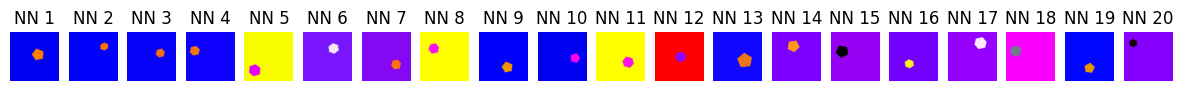

Prototype 18:
- Weight: 0.008972765877842903
- y value: 0.996735692024231
- nn_bound_circle_r_avg: 59.75
- nn_bound_circle_r_std: 3.9099232729044697


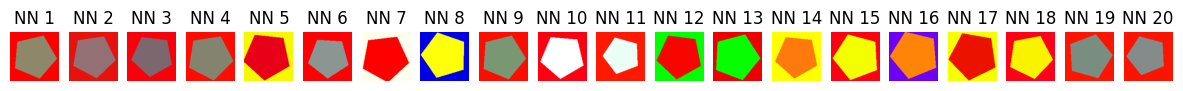

Prototype 29:
- Weight: 0.00817425362765789
- y value: 0.9535717964172363
- nn_bound_circle_r_avg: 52.45
- nn_bound_circle_r_std: 4.684815898197068


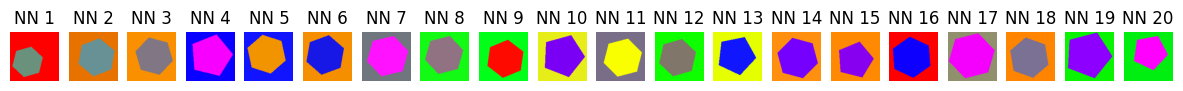

Prototype 39:
- Weight: 0.0077715483494102955
- y value: 0.9761337041854858
- nn_bound_circle_r_avg: 56.35
- nn_bound_circle_r_std: 3.8765319552404054


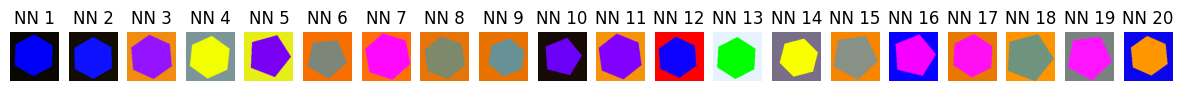

Prototype 45:
- Weight: 0.008648699149489403
- y value: 0.9882725477218628
- nn_bound_circle_r_avg: 59.75
- nn_bound_circle_r_std: 5.466946131068057


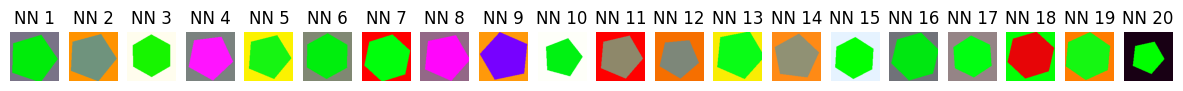

Prototype 53:
- Weight: 0.008170105516910553
- y value: 0.004425335209816694
- nn_bound_circle_r_avg: 15.45
- nn_bound_circle_r_std: 2.6358110706194404


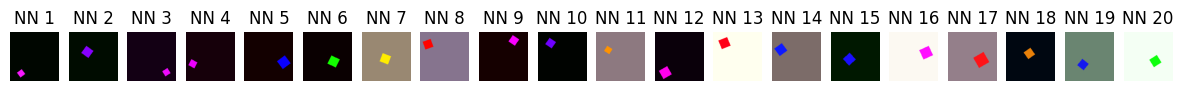

Prototype 59:
- Weight: 0.008023887872695923
- y value: 0.5215883255004883
- nn_bound_circle_r_avg: 36.15
- nn_bound_circle_r_std: 4.065402809070708


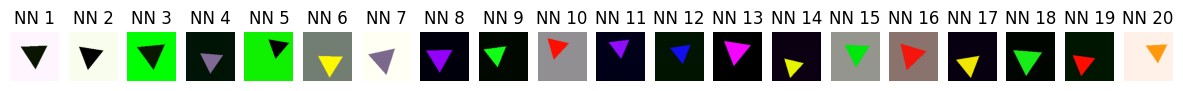

Prototype 67:
- Weight: 0.008586548268795013
- y value: 0.9896703958511353
- nn_bound_circle_r_avg: 59.95
- nn_bound_circle_r_std: 3.8532453853861943


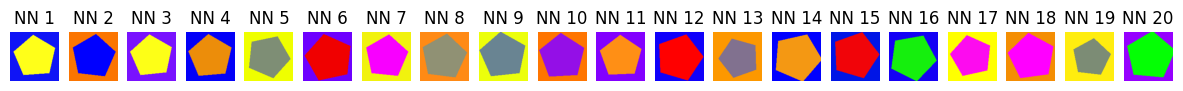

Prototype 77:
- Weight: 0.00793919526040554
- y value: 0.04216867685317993
- nn_bound_circle_r_avg: 18.7
- nn_bound_circle_r_std: 2.0024984394500787


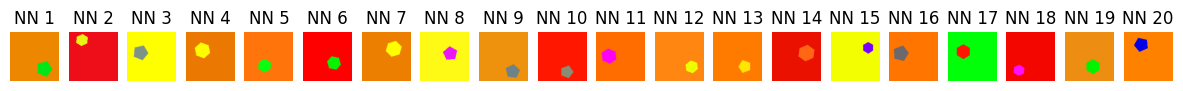

Prototype 85:
- Weight: 0.007595520466566086
- y value: 0.6902483105659485
- nn_bound_circle_r_avg: 40.5
- nn_bound_circle_r_std: 3.4713109915419564


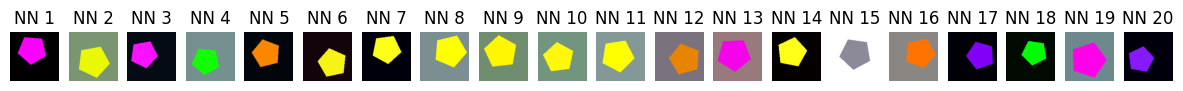

Prototype 97:
- Weight: 0.007748934905976057
- y value: 0.8348024487495422
- nn_bound_circle_r_avg: 47.65
- nn_bound_circle_r_std: 3.5954832776693593


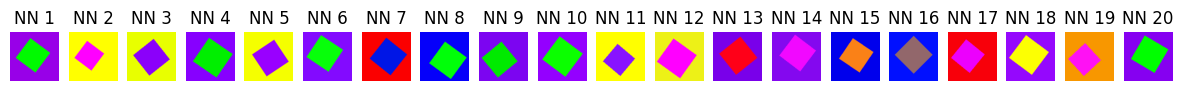

Prototype 104:
- Weight: 0.011528462171554565
- y value: 0.9671899676322937
- nn_bound_circle_r_avg: 51.25
- nn_bound_circle_r_std: 3.84545185901475


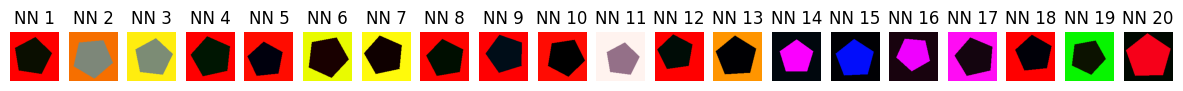

Prototype 112:
- Weight: 0.008465632796287537
- y value: 0.24225208163261414
- nn_bound_circle_r_avg: 29.5
- nn_bound_circle_r_std: 2.6739483914241875


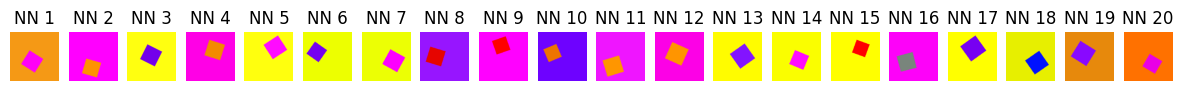

Prototype 117:
- Weight: 0.007975506596267223
- y value: 0.08936265856027603
- nn_bound_circle_r_avg: 23.2
- nn_bound_circle_r_std: 2.541653005427767


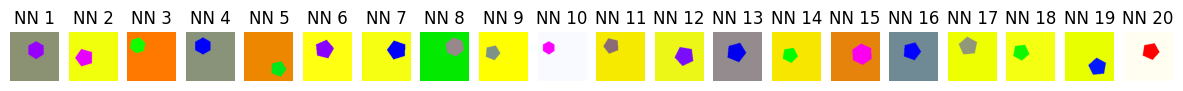

Prototype 124:
- Weight: 0.008063697256147861
- y value: 0.9377455115318298
- nn_bound_circle_r_avg: 49.0
- nn_bound_circle_r_std: 3.4641016151377544


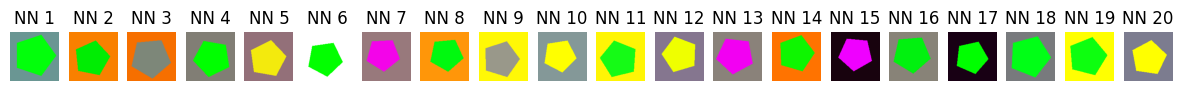

In [42]:
def plot_prototype_info(prototypes_df, train_df_encoded, images_path, prot_idx):
    """
    Prints information about a prototype and displays its nearest neighbor images.

    Args:
        prototypes_df (pd.DataFrame): DataFrame containing prototype information.
        train_df_encoded (pd.DataFrame): DataFrame containing encoded training data.
        images_path (str): Path to the folder containing the images.
        prot_idx (int): Index of the prototype to visualize.
    """
    # Print the weight and y value for the specified prototype
    print(f"Prototype {prot_idx}:")
    print(f"- Weight: {prototypes_df['w'][prot_idx]}")
    print(f"- y value: {prototypes_df['y'][prot_idx]}")
    print(f"- nn_bound_circle_r_avg: {prototypes_df['nn_bound_circle_r_avg'][prot_idx]}")
    print(f"- nn_bound_circle_r_std: {prototypes_df['nn_bound_circle_r_std'][prot_idx]}")

    # Show the NN images
    nn_indices = prototypes_df['nn_indices'][prot_idx]

    plt.figure(figsize=(15, 5))  # Adjust figure size as needed

    for i, img_idx in enumerate(nn_indices):
        img_path = images_path + "/" + train_df_encoded['filename'][img_idx]
        img = plt.imread(img_path)
        plt.subplot(1, len(nn_indices), i + 1)
        plt.imshow(img)
        plt.title(f"NN {i+1}")
        plt.axis('off')
    plt.show()


idxs = prototypes_df_top.index.values
for i in range(0, len(idxs), 5):
    plot_prototype_info(prototypes_df_top, train_df_encoded, images_path, idxs[i])

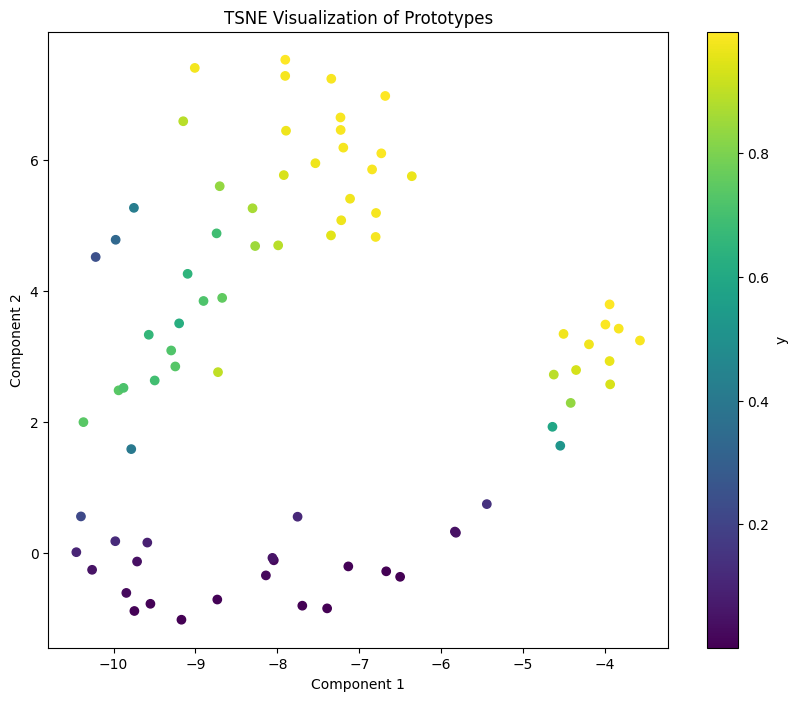

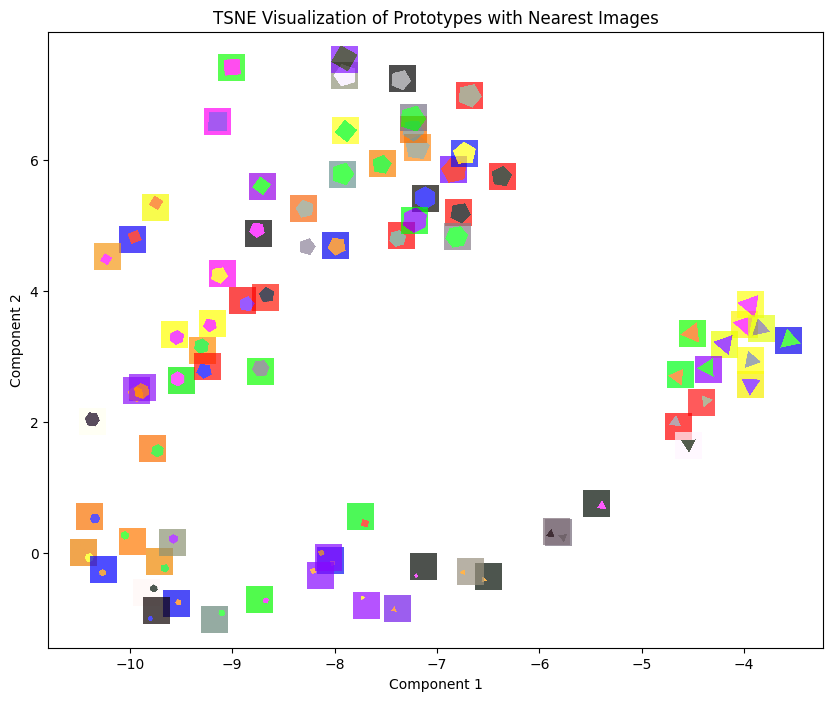

In [43]:
# prompt: Create a function that given a DF with prototypes create a 2-D visualization using t-sne

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE, MDS, Isomap, LocallyLinearEmbedding

def visualize_prototypes(prototypes_df, embed_class):
    """
    Creates a 2-D visualization of prototypes using t-SNE.

    Args:
        prototypes_df (pd.DataFrame): DataFrame containing prototype data,
            with a column 'x' representing the prototype encodings.
    """

    # Extract prototype encodings
    encodings = np.array(prototypes_df['x'].to_list())

    # Apply t-SNE
    # tsne = TSNE(n_components=2, random_state=42)  # You can adjust parameters here
    # embeddings = tsne.fit_transform(encodings)

    # apply MDS
    # mds = MDS(n_components=2, random_state=42)
    # embeddings = mds.fit_transform(encodings)

    # Apply Isomap
    embed_obj = embed_class(n_components=2)
    embeddings = embed_obj.fit_transform(encodings)

    # Apply LLE
    # lle = LocallyLinearEmbedding(n_components=2, random_state=41)
    # embeddings = lle.fit_transform(encodings)

    # Create the plot
    plt.figure(figsize=(10, 8))
    plt.scatter(embeddings[:, 0], embeddings[:, 1], c=prototypes_df['y'], cmap='viridis')
    plt.colorbar(label='y')
    plt.title(f'{embed_class.__name__} Visualization of Prototypes')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def visualize_prototypes_img(prototypes_df, train_df_encoded, images_path, embed_class):
    """
    Creates a 2-D visualization of prototypes using Isomap and displays closest images.

    Args:
        prototypes_df (pd.DataFrame): DataFrame containing prototype data.
        train_df_encoded (pd.DataFrame): DataFrame with encoded training data and filenames.
        images_path (str): Path to image directory.
    """

    encodings = np.array(prototypes_df['x'].to_list())

    embed_obj = embed_class(n_components=2)
    embeddings = embed_obj.fit_transform(encodings)

    # Apply LLE
    # lle = LocallyLinearEmbedding(n_components=2, random_state=41)
    # embeddings = lle.fit_transform(encodings)


    indexes = prototypes_df.index.values

    fig, ax = plt.subplots(figsize=(10, 8))  # Create a single figure and axes
    ax.scatter(embeddings[:, 0], embeddings[:, 1], c=prototypes_df['y'], cmap='viridis', s=0)

    for i, embedding in enumerate(embeddings):
        nn_indices = prototypes_df['nn_indices'][indexes[i]]
        closest_image_idx = nn_indices[0]
        img_path = os.path.join(images_path, train_df_encoded['filename'][closest_image_idx])
        try:
            img = plt.imread(img_path)
            # Create an OffsetImage for each image
            imagebox = OffsetImage(img, zoom=0.15, alpha=0.7)  # Adjust zoom as needed
            ab = AnnotationBbox(imagebox, embedding, frameon=False)
            ax.add_artist(ab)
        except FileNotFoundError:
            print(f"Image not found at: {img_path}")

    plt.title(f'{embed_class.__name__} Visualization of Prototypes with Nearest Images')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()  # Display the plot after adding all images

visualize_prototypes(prototypes_df_top, TSNE)
visualize_prototypes_img(prototypes_df_top, train_df_encoded, images_path, TSNE)


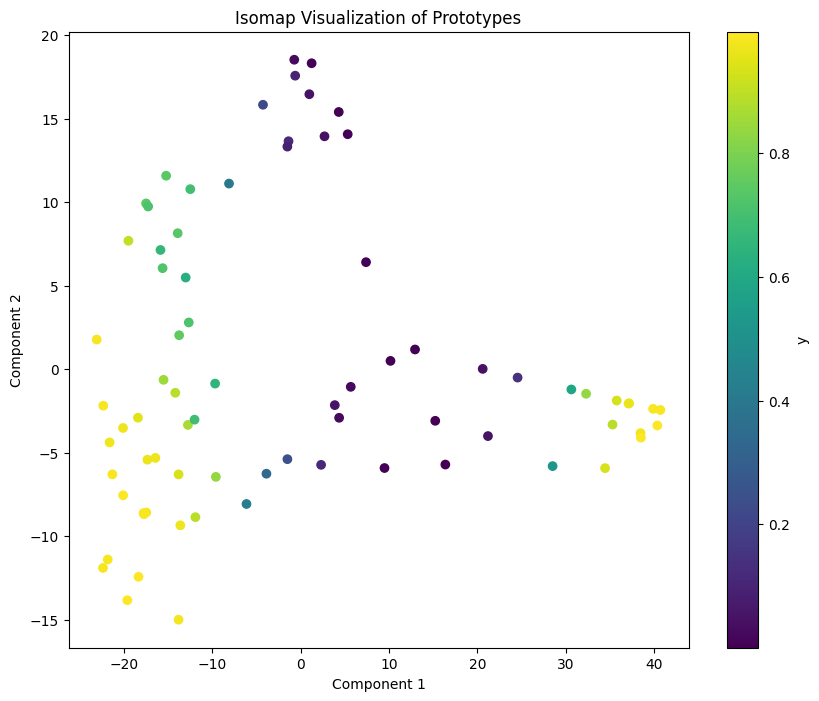

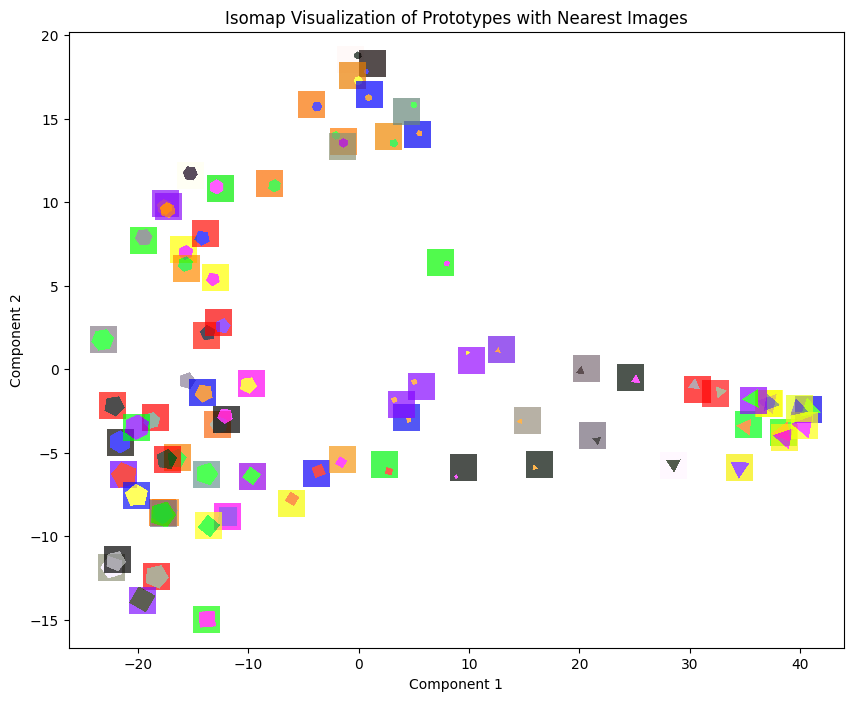

In [44]:
visualize_prototypes(prototypes_df_top, Isomap)
visualize_prototypes_img(prototypes_df_top, train_df_encoded, images_path, Isomap)


In [45]:
y_pred, y_var = kdm_gen_adj.predict_reg(test_ds)

# Create a copy of train_df
test_df_pred = test_df.copy()

#reset indices
test_df_pred.reset_index(drop=True, inplace=True)

# Add the encoding vector as a new column
test_df_pred['y_pred'] = y_pred.tolist()
test_df_pred['y_var'] = y_var.tolist()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [46]:
from kdm.utils import dm2comp, dm_rbf_loglik

def img_pred_plot(img):
    image = transform_image(img)
    image = image.to(device)
    with torch.no_grad():
        outputs = dinov2_vits14(image[None, ...])
        img_emb = outputs.cpu().detach().numpy()
    x = np.atleast_2d(np.linspace(0, 1, 1000)).T
    rho_y = keras.ops.cast(kdm_gen_adj.predict(img_emb), dtype='float32')
    y_pred, y_var = kdm_gen_adj.predict_reg(img_emb)
    print(f'y_pred: {y_pred}, y_var: {y_var}')
    sigma_y = keras.ops.clip(kdm_gen_adj.sigma_y, kdm_gen_adj.min_sigma_y, np.inf)
    loglik = dm_rbf_loglik(keras.ops.convert_to_tensor(x, dtype="float32"),rho_y,sigma_y)
    lik = keras.ops.convert_to_numpy(keras.ops.exp(loglik))

    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plt.plot(x, lik)
    plt.xlabel('y')
    plt.ylabel('Probability density')
    plt.ylim(0, 5)
    plt.title("Predicted PDF")
    w, v = dm2comp(rho_y)
    w = keras.ops.convert_to_numpy(w)
    v = keras.ops.convert_to_numpy(v)
    idx_sort = np.argsort(-w[0])
    plt.subplot(1, 2, 2)
    plt.plot(np.arange(len(w[0])), w[0])
    plt.xlabel('idx')
    plt.ylabel('Prototype Weight')
    plt.title("Weight")
    plt.show()
    plt.figure(figsize=(12.5, 1.5))  # Adjust figure size as needed
    for i in range(5):
        nn_indices = prototypes_df['nn_indices'][idx_sort[i]]
        closest_image_idx = nn_indices[0]
        img_path = os.path.join(images_path, train_df_encoded['filename'][closest_image_idx])
        try:
            plt.subplot(1, 5, i + 1)
            img = plt.imread(img_path)
            plt.imshow(img)
            plt.title(f"W: {w[0, idx_sort[i]]:.3f} y:{v[0, idx_sort[i], 0]:.3f}",
                      fontsize=8)
            plt.axis('off')
        except FileNotFoundError:
            print(f"Image not found at: {img_path}")
    plt.show()






Index: 1419 y_pred: [0.632197380065918], y_var: 0.1541985720396042, label: 1.0


<Figure size 500x300 with 0 Axes>

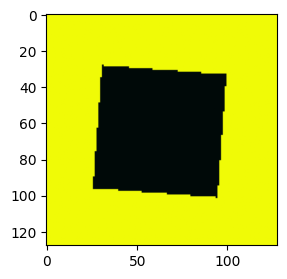

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
y_pred: [[0.63219786]], y_var: [0.15419851]


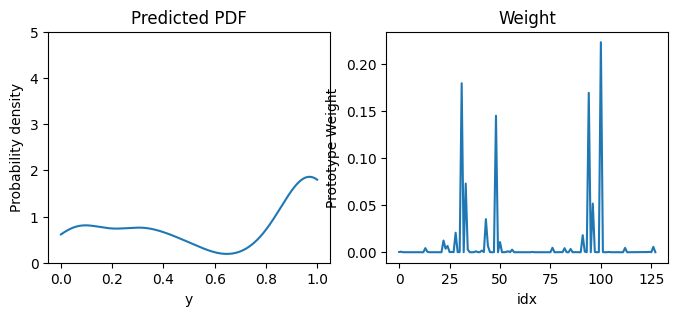

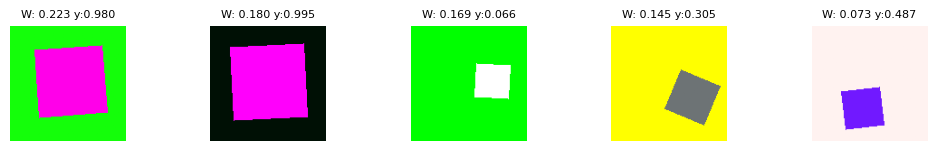



Index: 1842 y_pred: [0.5318310260772705], y_var: 0.13037149608135223, label: 1.0


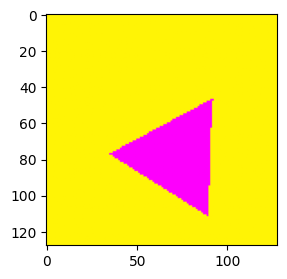

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
y_pred: [[0.5318327]], y_var: [0.13037132]


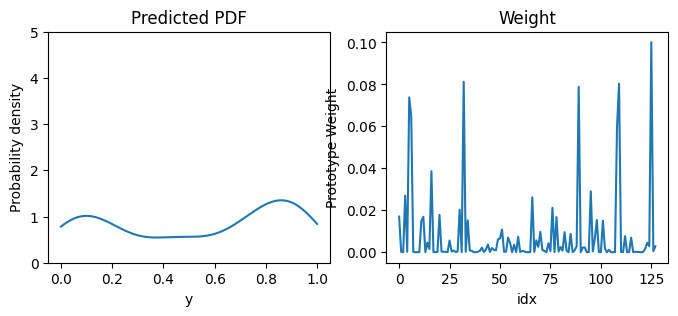

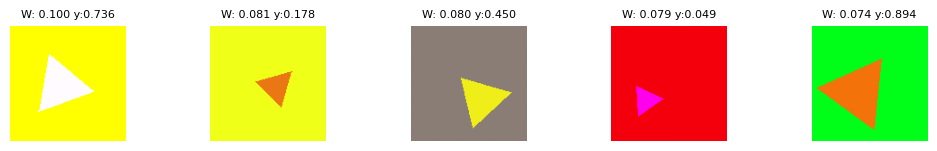



Index: 1077 y_pred: [0.5057699680328369], y_var: 0.1300591081380844, label: 1.0


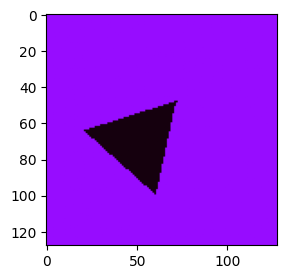

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
y_pred: [[0.50576955]], y_var: [0.13005896]


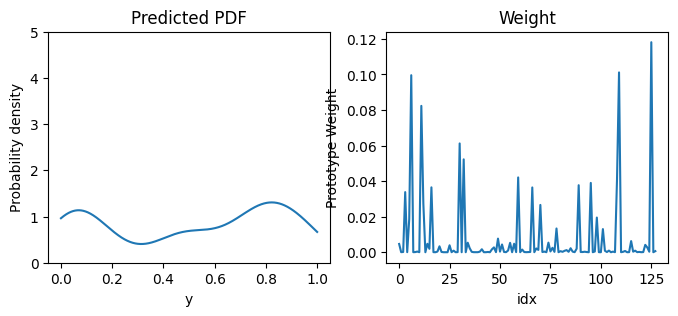

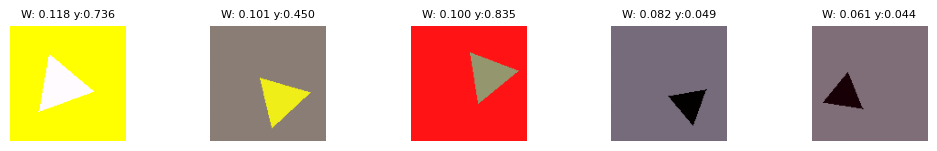



Index: 619 y_pred: [0.47902435064315796], y_var: 0.129414364695549, label: 1.0


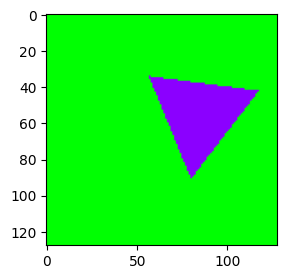

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
y_pred: [[0.47902432]], y_var: [0.12941436]


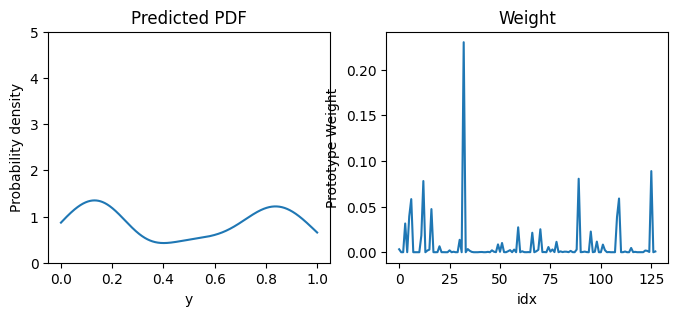

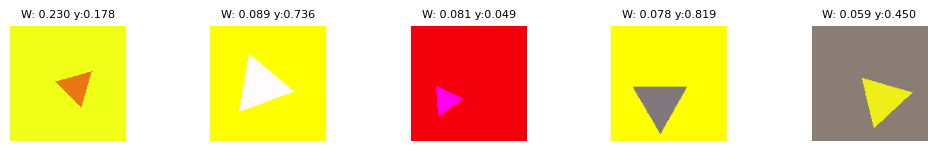



Index: 807 y_pred: [0.5250697731971741], y_var: 0.12850479781627655, label: 1.0


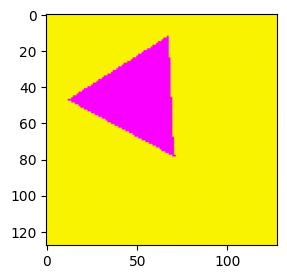

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
y_pred: [[0.5250688]], y_var: [0.12850498]


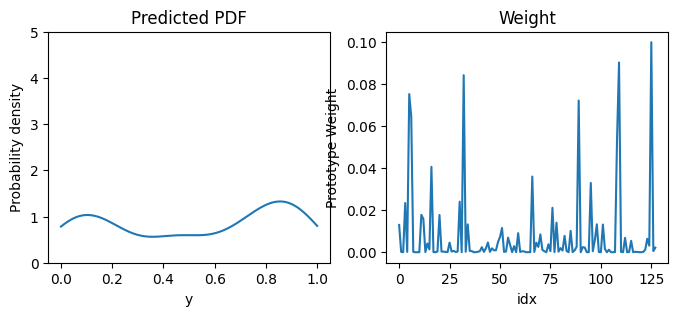

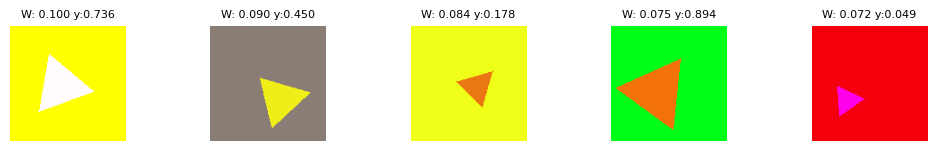



Index: 14 y_pred: [0.5370595455169678], y_var: 0.1281871646642685, label: 1.0


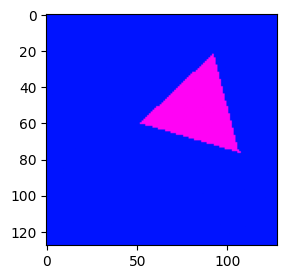

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
y_pred: [[0.53705966]], y_var: [0.12818722]


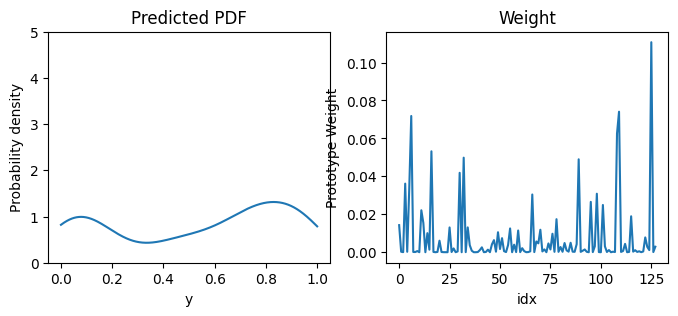

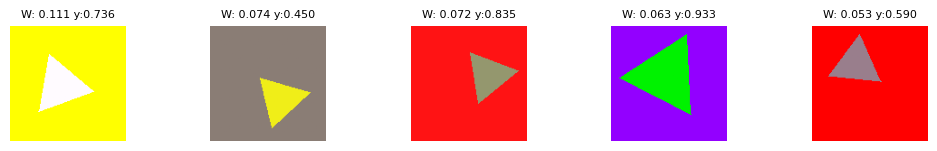



Index: 269 y_pred: [0.43359291553497314], y_var: 0.1274327039718628, label: 1.0


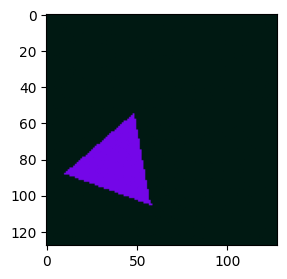

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
y_pred: [[0.4335926]], y_var: [0.12743269]


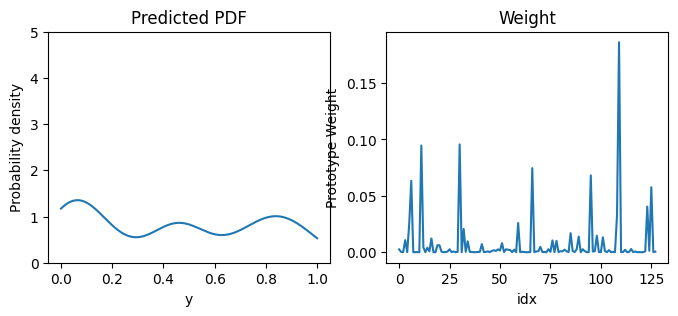

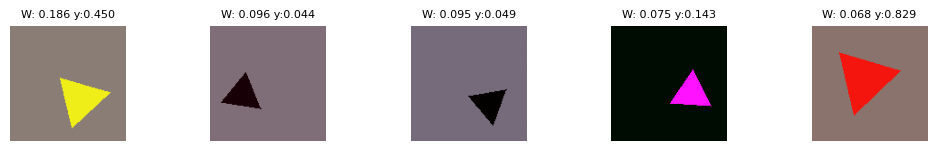



Index: 140 y_pred: [0.45213016867637634], y_var: 0.12715822458267212, label: 1.0


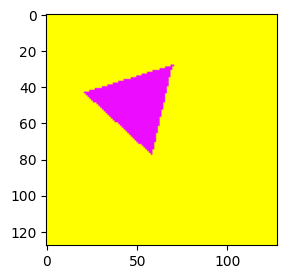

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
y_pred: [[0.45213014]], y_var: [0.12715818]


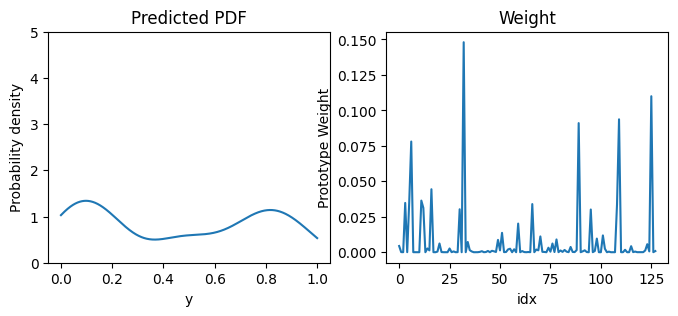

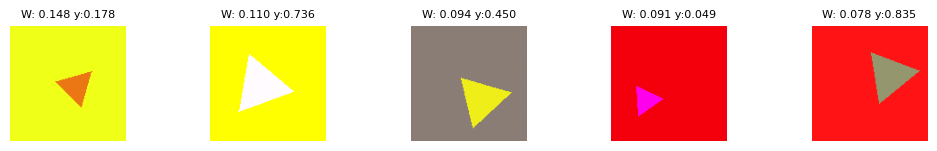



Index: 1374 y_pred: [0.5640826225280762], y_var: 0.12545810639858246, label: 1.0


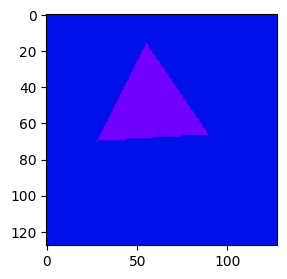

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
y_pred: [[0.56408054]], y_var: [0.12545834]


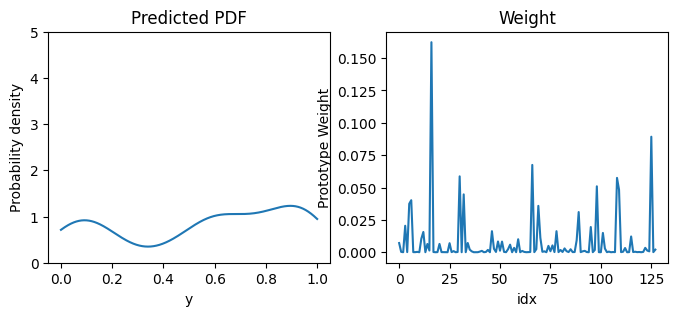

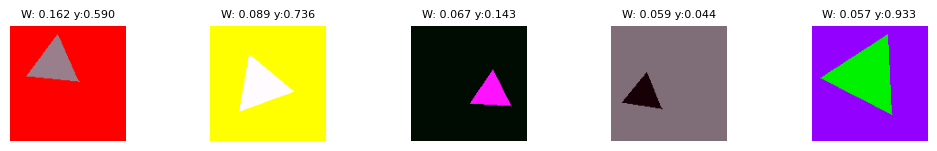



Index: 1744 y_pred: [0.38127151131629944], y_var: 0.1238236129283905, label: 1.0


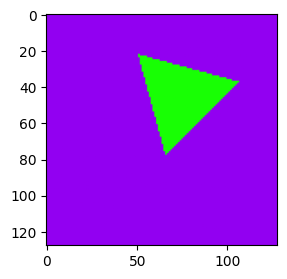

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
y_pred: [[0.38127202]], y_var: [0.12382367]


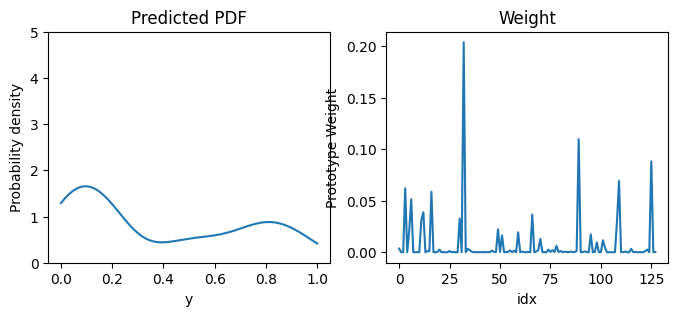

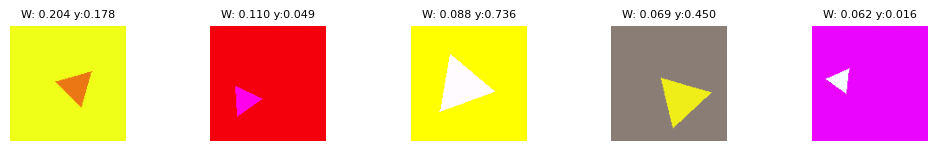



Index: 607 y_pred: [0.507584810256958], y_var: 0.12298594415187836, label: 1.0


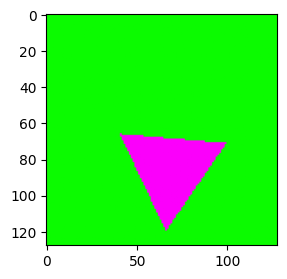

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
y_pred: [[0.50758415]], y_var: [0.122986]


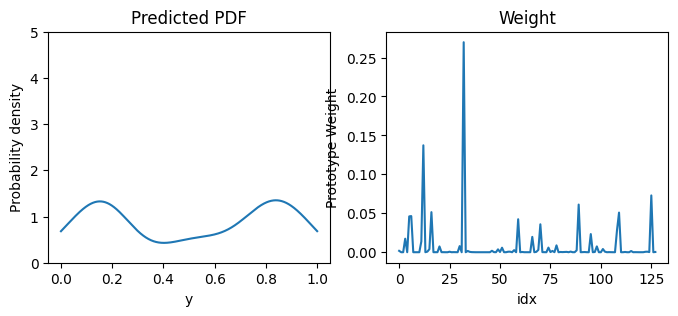

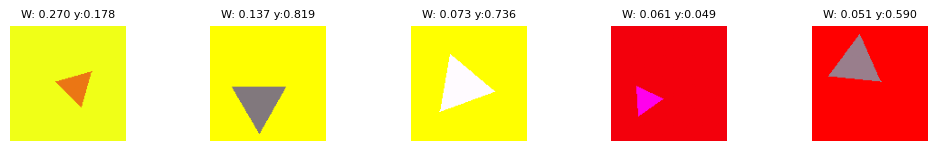



Index: 919 y_pred: [0.6225247383117676], y_var: 0.12172369658946991, label: 1.0


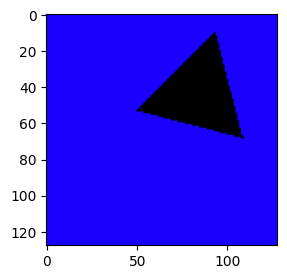

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
y_pred: [[0.6225264]], y_var: [0.12172319]


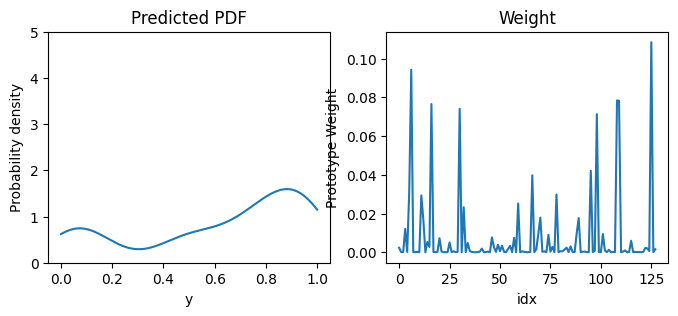

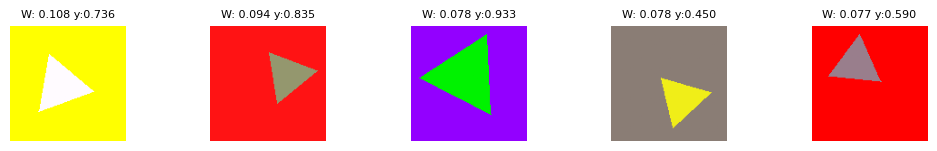



Index: 1234 y_pred: [0.3303050994873047], y_var: 0.12154105305671692, label: 1.0


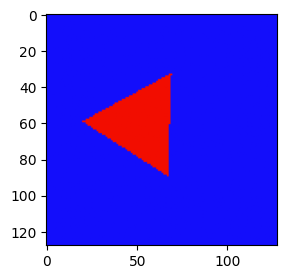

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
y_pred: [[0.33030635]], y_var: [0.12154128]


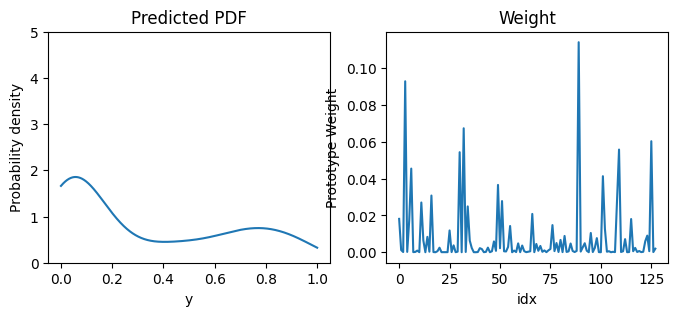

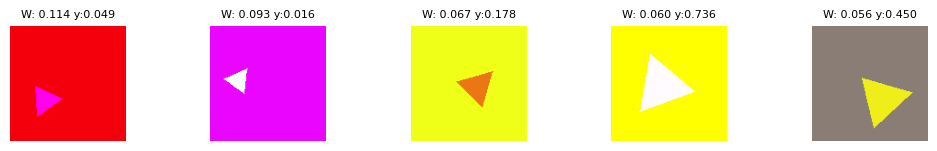



Index: 174 y_pred: [0.3668343126773834], y_var: 0.12145903706550598, label: 1.0


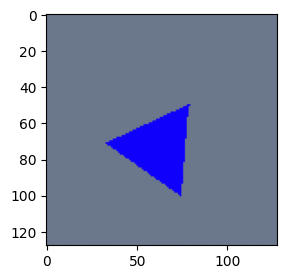

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
y_pred: [[0.36683208]], y_var: [0.12145883]


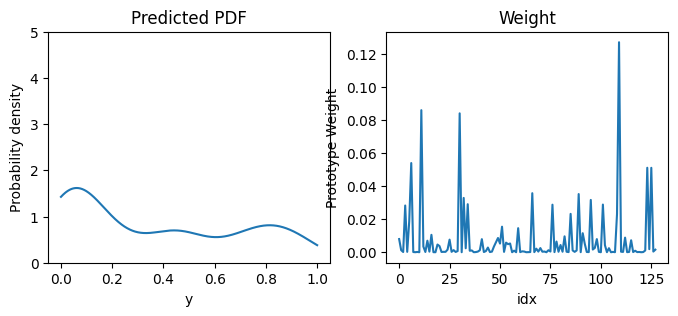

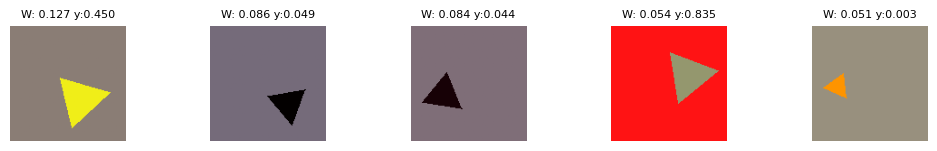



Index: 732 y_pred: [0.3386262357234955], y_var: 0.12138953804969788, label: 1.0


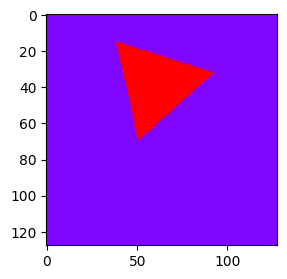

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
y_pred: [[0.3386259]], y_var: [0.12138943]


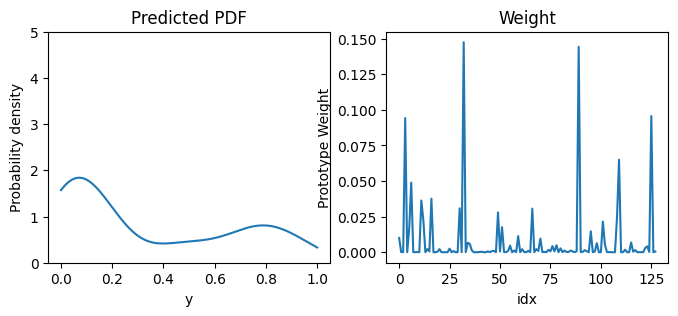

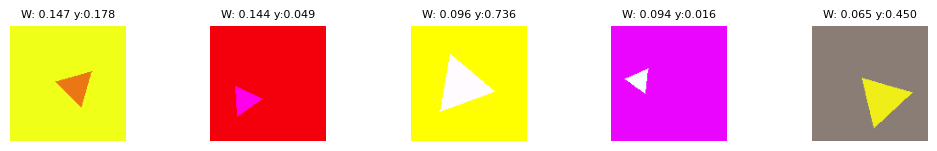



Index: 1041 y_pred: [0.5142053365707397], y_var: 0.12069176137447357, label: 1.0


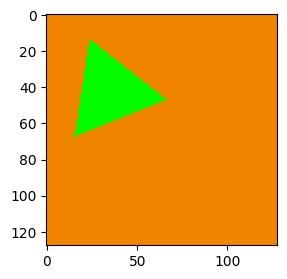

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
y_pred: [[0.5142064]], y_var: [0.12069176]


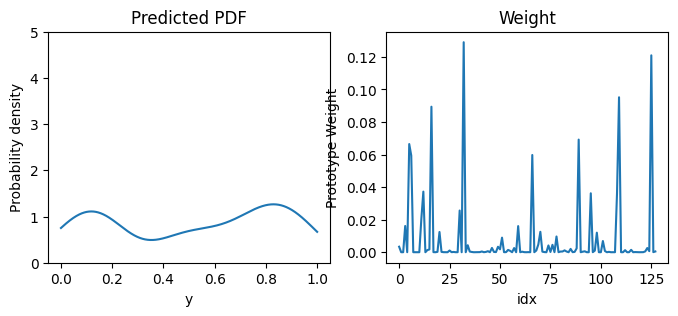

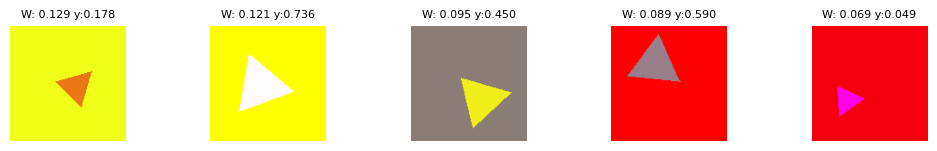



Index: 1784 y_pred: [0.4820604622364044], y_var: 0.12067145109176636, label: 1.0


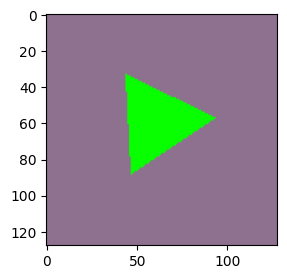

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
y_pred: [[0.48206043]], y_var: [0.12067138]


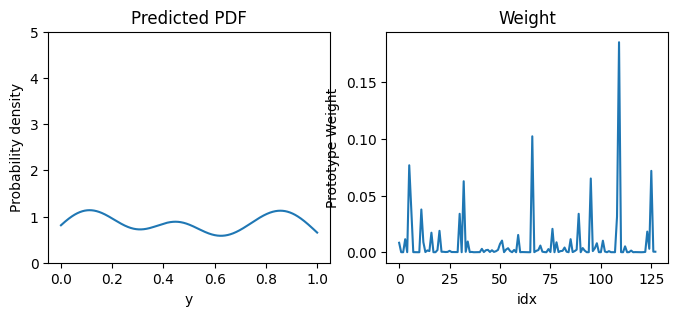

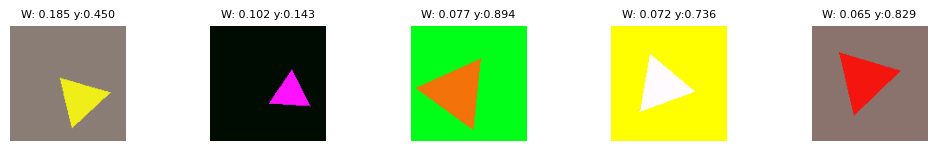



Index: 611 y_pred: [0.45755115151405334], y_var: 0.12052716314792633, label: 1.0


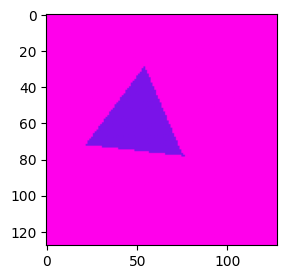

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
y_pred: [[0.45755157]], y_var: [0.12052706]


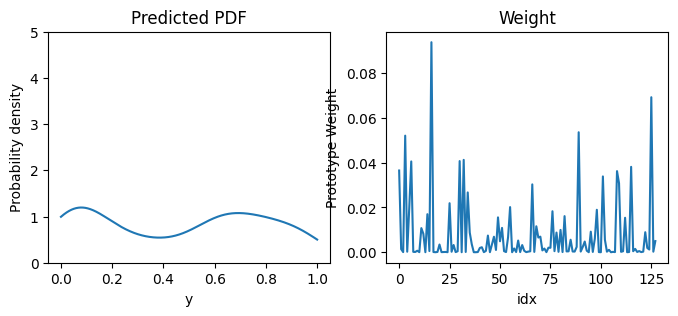

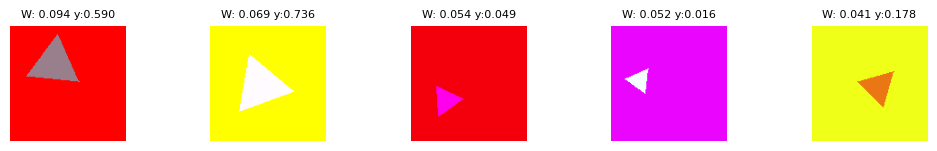



Index: 410 y_pred: [0.3818283975124359], y_var: 0.12043820321559906, label: 1.0


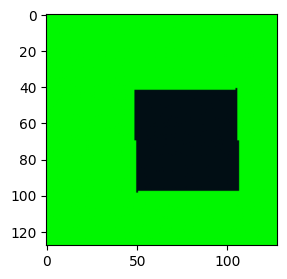

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
y_pred: [[0.381829]], y_var: [0.12043886]


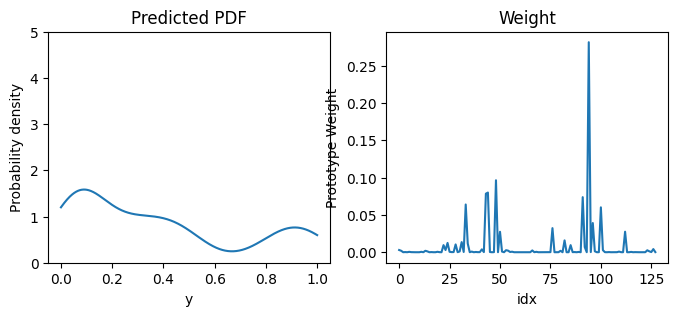

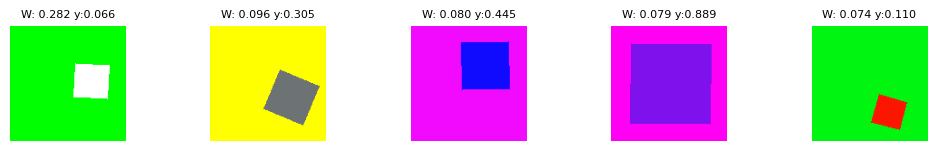



Index: 91 y_pred: [0.5869691967964172], y_var: 0.1200842410326004, label: 1.0


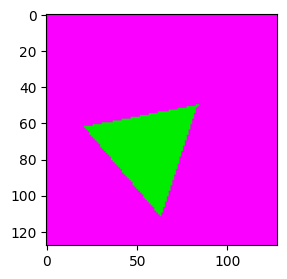

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
y_pred: [[0.5869692]], y_var: [0.12008412]


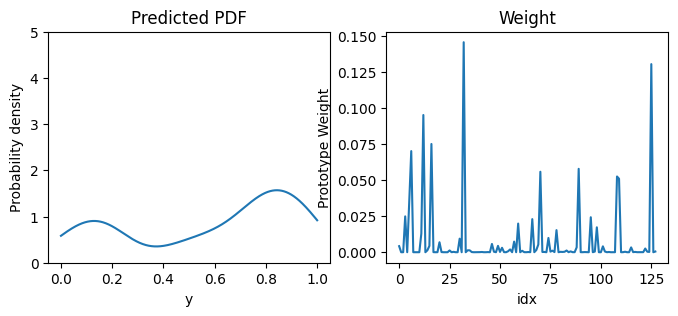

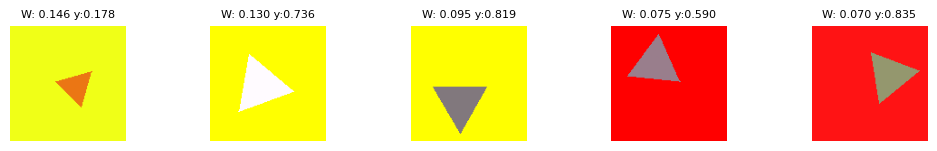



Index: 11 y_pred: [0.3525702655315399], y_var: 0.11995894461870193, label: 1.0


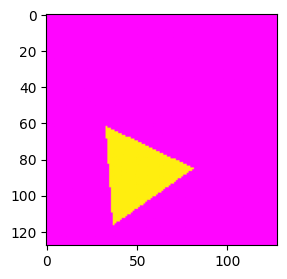

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
y_pred: [[0.3525732]], y_var: [0.11995942]


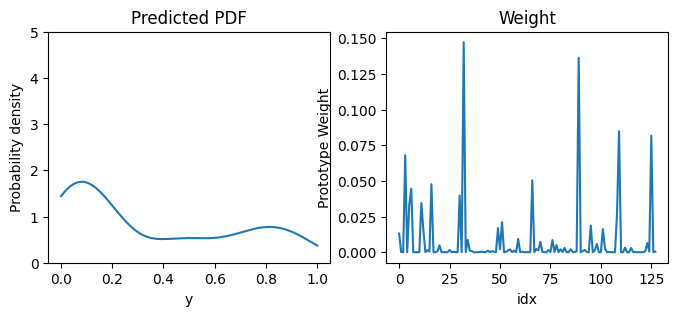

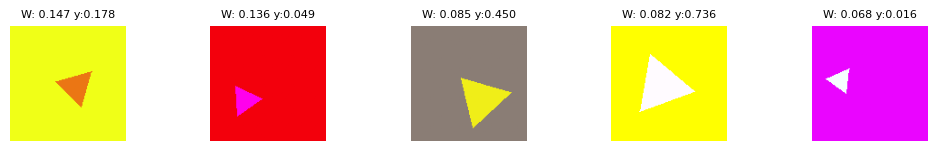



Index: 422 y_pred: [0.3529645800590515], y_var: 0.11980932205915451, label: 1.0


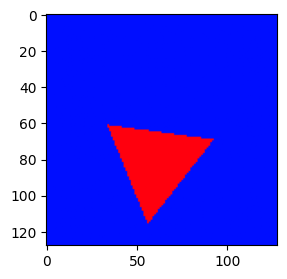

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
y_pred: [[0.35296443]], y_var: [0.11980941]


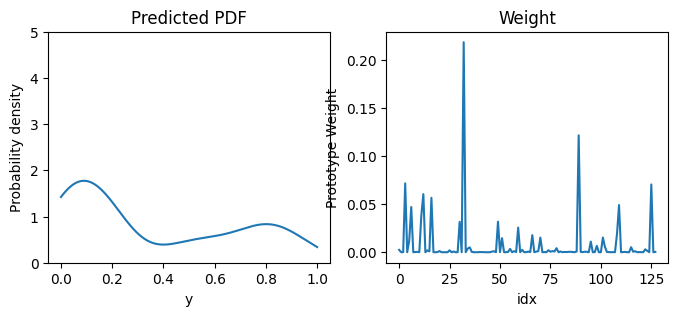

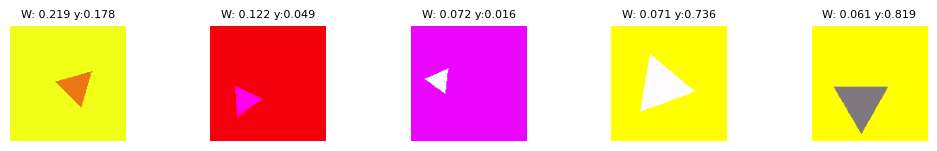



Index: 1339 y_pred: [0.46298813819885254], y_var: 0.11957141757011414, label: 1.0


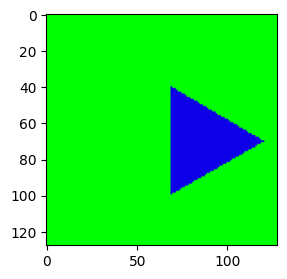

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
y_pred: [[0.46298856]], y_var: [0.11957145]


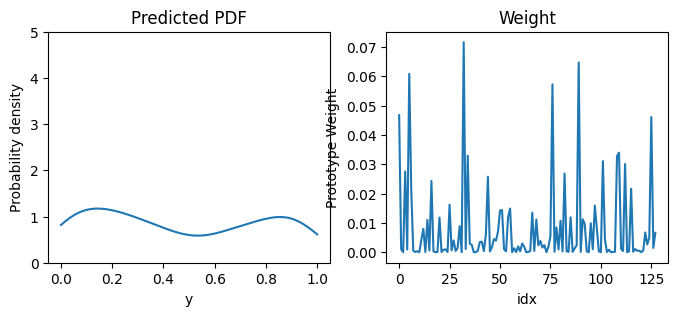

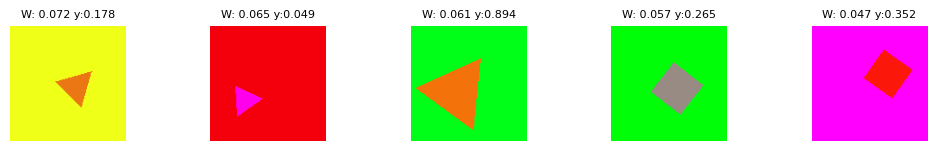



Index: 42 y_pred: [0.5673889517784119], y_var: 0.11849923431873322, label: 1.0


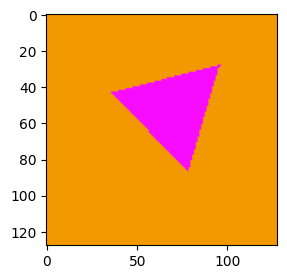

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
y_pred: [[0.56739026]], y_var: [0.11849888]


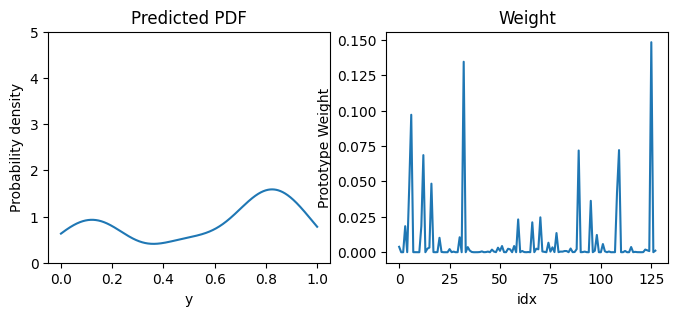

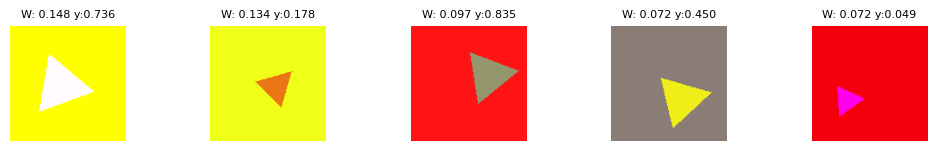



Index: 1088 y_pred: [0.39320108294487], y_var: 0.11758051812648773, label: 1.0


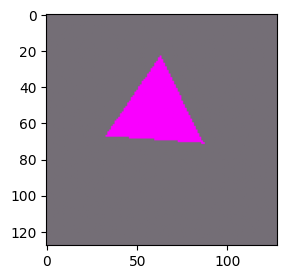

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
y_pred: [[0.39319968]], y_var: [0.11758031]


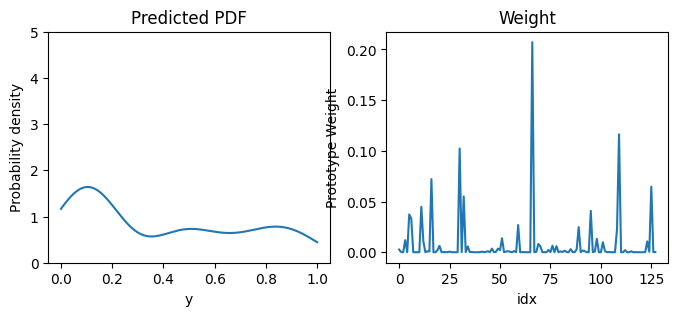

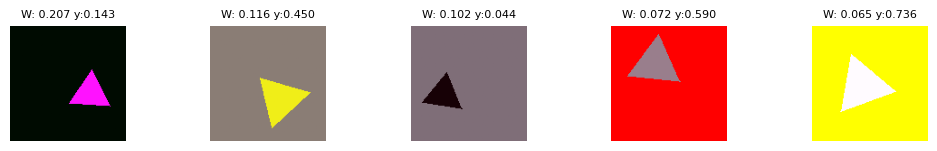



Index: 984 y_pred: [0.32327961921691895], y_var: 0.1164642721414566, label: 1.0


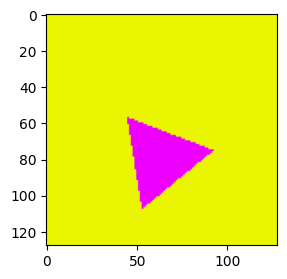

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
y_pred: [[0.32327813]], y_var: [0.11646388]


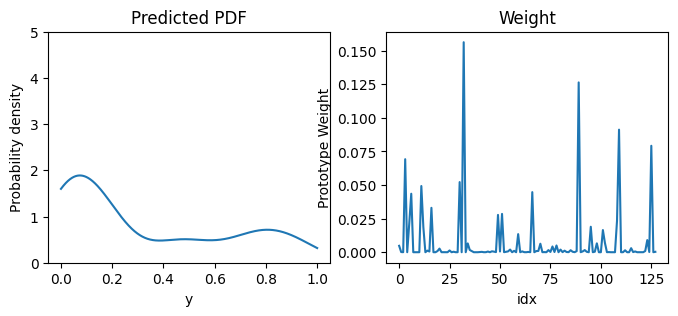

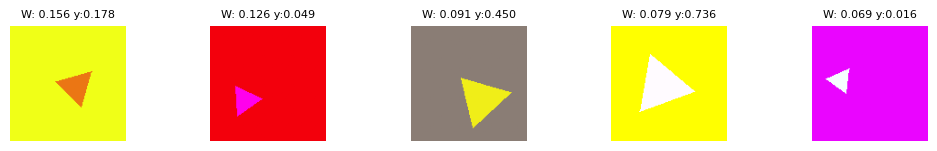



Index: 874 y_pred: [0.46084660291671753], y_var: 0.116309255361557, label: 1.0


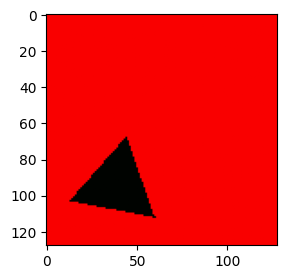

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
y_pred: [[0.46084583]], y_var: [0.11630917]


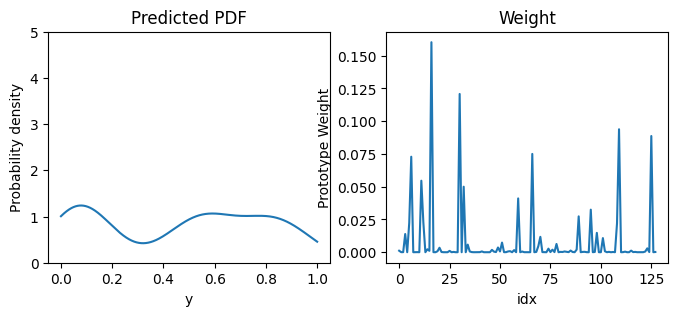

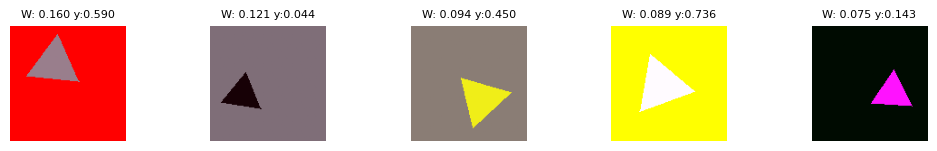



Index: 1181 y_pred: [0.39072155952453613], y_var: 0.11580926179885864, label: 1.0


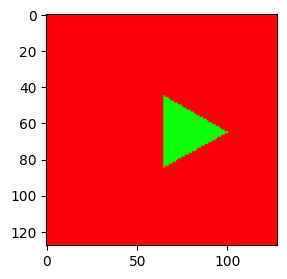

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
y_pred: [[0.39072058]], y_var: [0.1158091]


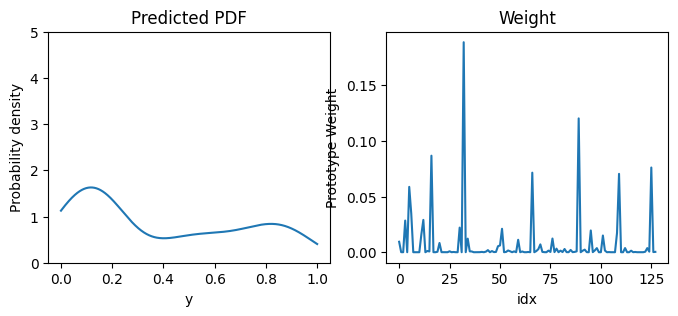

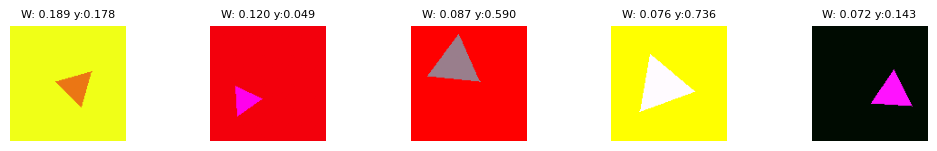



Index: 399 y_pred: [0.45574286580085754], y_var: 0.1152440756559372, label: 1.0


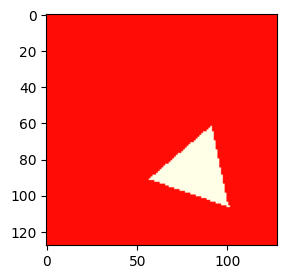

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
y_pred: [[0.45574299]], y_var: [0.11524406]


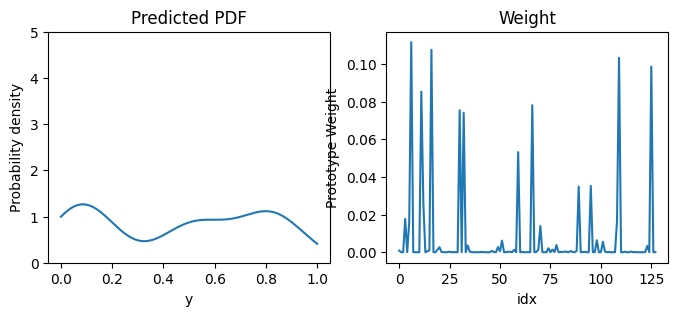

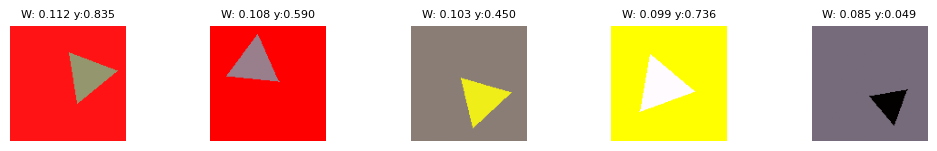



Index: 151 y_pred: [0.5660079121589661], y_var: 0.11469288170337677, label: 1.0


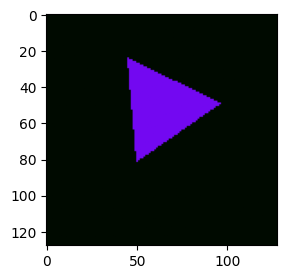

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
y_pred: [[0.56600904]], y_var: [0.11469261]


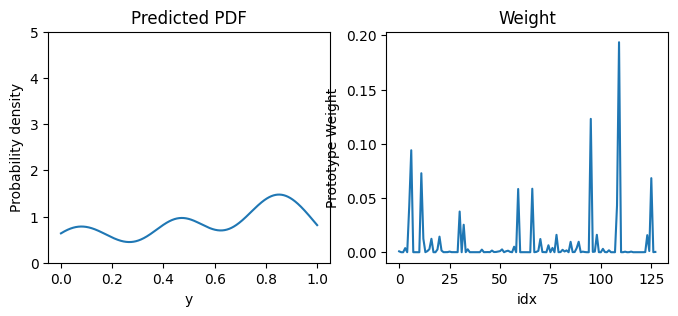

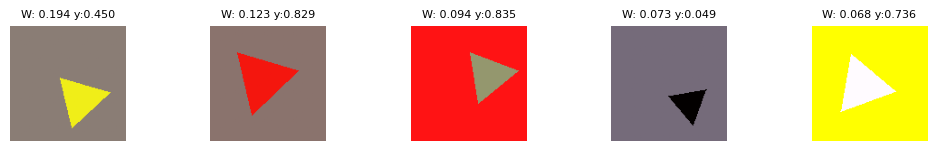

<Figure size 640x480 with 0 Axes>

In [47]:
# prompt: Get the top n images from test_df_pred with largest y_var

# Assuming test_df_pred is defined and contains 'y_var' and 'filename' columns.
# Also assuming images_path is defined.

import matplotlib.pyplot as plt
import os

# Sort test_df_pred by y_var in descending order and get the top n
n = 30
top_n_images = test_df_pred.sort_values('y_var', ascending=False).head(n)

# Display the top n images
plt.figure(figsize=(5, 3))  # Adjust figure size as needed

for i, (index, row) in enumerate(top_n_images.iterrows()):
    img_path = os.path.join(images_path, row['filename'])
    try:
        label = (row['bound_circle_r'] >= 0.5) * 1.
        print(f'\n\nIndex: {index} y_pred: {row["y_pred"]}, y_var: {row["y_var"]}, label: {label}')
        plt.figure(figsize=(5, 3))  # Adjust figure size as needed
        img = plt.imread(img_path)
        plt.imshow(img)
        plt.show()
        img_pred_plot(img)
    except FileNotFoundError:
        print(f"Image not found at: {img_path}")

plt.tight_layout()  # Adjust layout to prevent overlapping titles
plt.show()

In [52]:
encoder = create_encoder(input_shape=input_shape, layer_sizes=layer_sizes)
print(encoder.summary())
# warm up the encoder with a small subset
encoder_wmp = keras.Sequential([encoder,
                                #keras.layers.Dense(256, activation='gelu'),
                                keras.layers.Dense(1, activation='sigmoid')])
encoder_wmp.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                loss=losses.binary_crossentropy,
                metrics=[metrics.binary_accuracy])

# train the encoder for 2 epoch
subset_ds = train_ds
encoder_wmp.fit(subset_ds, epochs=5, verbose=1)

pred_nn = encoder_wmp.predict(test_ds)
test_df['pred_nn'] = pred_nn[:, 0]

pred_kdm_reg, var = kdm_gen_adj.predict_reg(test_ds)
test_df['pred_kdm_reg'] = pred_kdm_reg[:, 0]
test_df['var_kdm'] = var

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │          12,320 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,320 (48.12 KB)

 Trainable params: 12,320 (48.12 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - binary_accuracy: 0.7732 - loss: 0.5286
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - binary_accuracy: 0.8968 - loss: 0.2498
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - binary_accuracy: 0.8879 - loss: 0.2666
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.8946 - loss: 0.2581
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.9038 - loss: 0.2255
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


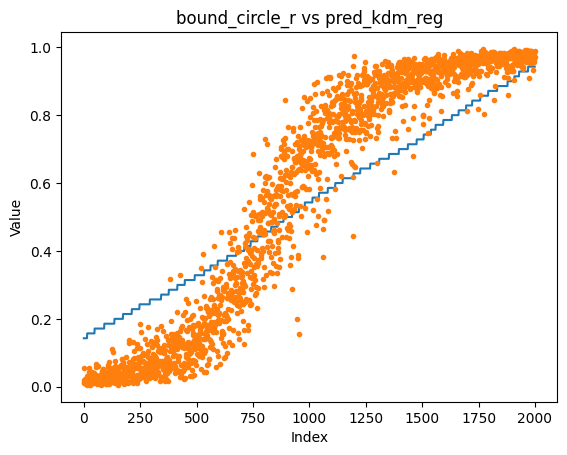

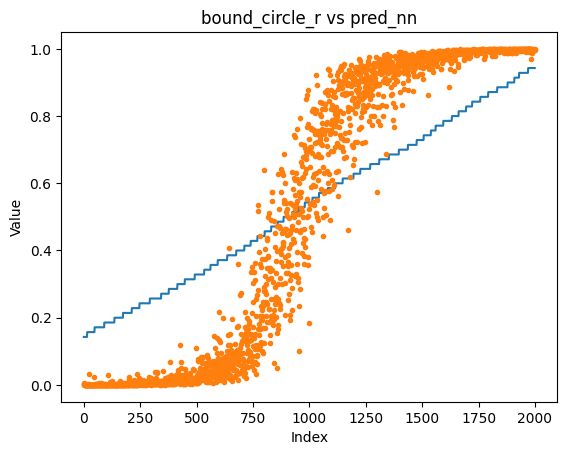

In [53]:
# prompt: Sort test_df by ' bound_circle_r' column

test_df_sorted = test_df.sort_values(by='bound_circle_r')

# plot values in 'bound_circle_r'
plt.plot(range(len(test_df_sorted)), test_df_sorted['bound_circle_r'] / 70)
plt.plot(range(len(test_df_sorted)), test_df_sorted['pred_kdm_reg'], '.')
plt.title('bound_circle_r vs pred_kdm_reg')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

plt.plot(range(len(test_df_sorted)), test_df_sorted['bound_circle_r'] / 70)
plt.plot(range(len(test_df_sorted)), test_df_sorted['pred_nn'], '.')
plt.title('bound_circle_r vs pred_nn')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()




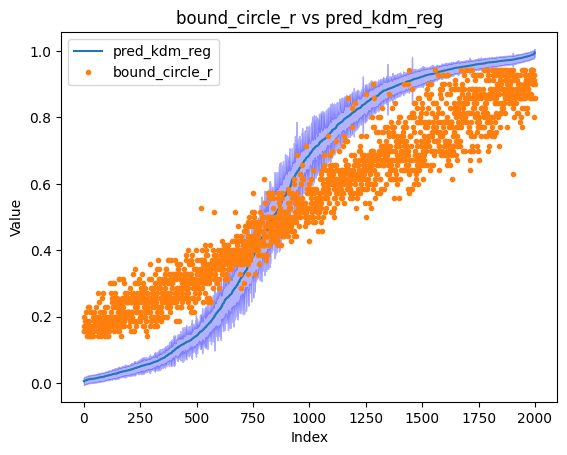

In [55]:
# prompt: Sort test_df by ' bound_circle_r' column

test_df_sorted = test_df.sort_values(by='pred_kdm_reg')

# plot values in 'bound_circle_r'
plt.plot(range(len(test_df_sorted)), test_df_sorted['pred_kdm_reg'], label='pred_kdm_reg')
# Plot a confidence region for pred_kdm_reg using the variance in var_kdm_reg
up_value = test_df_sorted['pred_kdm_reg'].to_numpy() + test_df_sorted['var_kdm'].to_numpy()
low_value = test_df_sorted['pred_kdm_reg'].to_numpy() - test_df_sorted['var_kdm'].to_numpy()
plt.fill_between(range(len(test_df_sorted)), low_value, up_value, color='blue', alpha=0.3)

plt.plot(range(len(test_df_sorted)), test_df_sorted['bound_circle_r'] / 70, '.', label='bound_circle_r')
plt.legend()
plt.title('bound_circle_r vs pred_kdm_reg')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

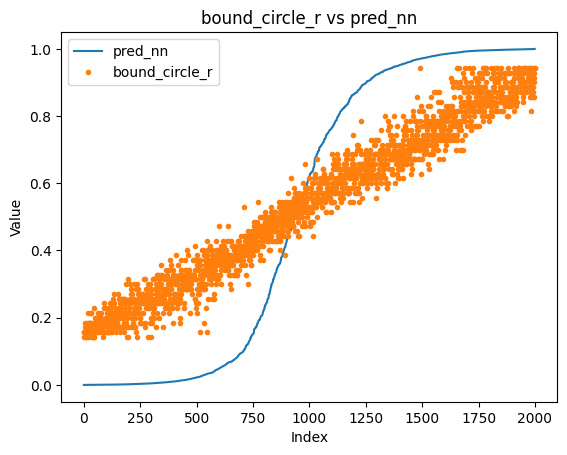

In [56]:
# prompt: Sort test_df by ' bound_circle_r' column

test_df_sorted = test_df.sort_values(by='pred_nn')

# plot values in 'bound_circle_r'
plt.plot(range(len(test_df_sorted)), test_df_sorted['pred_nn'], label='pred_nn')

plt.plot(range(len(test_df_sorted)), test_df_sorted['bound_circle_r'] / 70, '.', label='bound_circle_r')
plt.legend()
plt.title('bound_circle_r vs pred_nn')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()